# ADA Project Outline
1. load HKO provided data and preprocess
2. model training and evaluation
3. generate predictions

## Environment Setup

**Run the cell below first** to install required dependencies (pandas, numpy, scikit-learn, matplotlib, statsmodels, tensorflow, etc.). Skip if your environment is already set up.

In [1]:
# ========== Environment setup: run this cell first ==========
import subprocess
import sys

def _flush():
    if hasattr(sys.stdout, 'flush'):
        sys.stdout.flush()

print("Environment setup starting...")
_flush()

def install_requirements():
    """Install packages from requirements.txt if present."""
    try:
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"
        ], timeout=300)
        print("Install from requirements.txt done.")
    except FileNotFoundError:
        print("requirements.txt not found, installing core dependencies.")
        for pkg in ["pandas>=1.3.0", "numpy>=1.20.0", "scikit-learn>=1.0.0", 
                    "matplotlib>=3.4.0", "statsmodels>=0.13.0", "tensorflow>=2.8.0"]:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg], timeout=120)
    except subprocess.CalledProcessError:
        print("Some packages failed to install. Please run manually: pip install -r requirements.txt")
    except Exception as e:
        print("Install error:", e)

try:
    install_requirements()
except Exception as e:
    print("Setup warning:", e)

# Check and print versions
print("\nPython:", sys.version.split()[0])
for name, pkg in [
    ("pandas", "pandas"), ("numpy", "numpy"), ("sklearn", "scikit-learn"),
    ("matplotlib", "matplotlib"), ("statsmodels", "statsmodels")
]:
    try:
        mod = __import__(name)
        print(f"  {pkg}: {getattr(mod, '__version__', 'ok')}")
    except ImportError:
        print(f"  {pkg}: not installed")

try:
    import tensorflow as tf
    print(f"  tensorflow: {tf.__version__} (LSTM available)")
except ImportError:
    print("  tensorflow: not installed, LSTM cells will be skipped")

print("\nEnvironment check done. You can run the rest of the notebook.")
_flush()

Environment setup starting...
Install from requirements.txt done.

Python: 3.13.5
  pandas: 2.3.3
  numpy: 2.3.3
  scikit-learn: 1.7.1
  matplotlib: 3.10.6
  statsmodels: 0.14.6
  tensorflow: 2.20.0 (LSTM available)

Environment check done. You can run the rest of the notebook.


## 1. load HKO provided data and preprocess
All datasets are downloaded from https://data.gov.hk/sc-datasets/category/climate-and-weather  
All data are collected at the Hong Kong Observatory  
### 1.1 load raw data
The raw csv contains over a century of data. In this project, we only take the most recent 15 years, from 2011 to 2025  
Output the consolidated raw data as data/dataset_raw.csv

In [3]:
# Reload new CSV files, clean completeness, and merge into one dataset
import pandas as pd

# Required column order in the final table
file_to_feature = [
    ("data/t_max.csv", "T_max"),
    ("data/t_min.csv", "T_min"),
    ("data/rain.csv", "rain_mm"),
    ("data/RH.csv", "RH_mean"),
    ("data/cloud.csv", "cloud"),
    ("data/MSLP.csv", "MSLP"),
]

def load_one_hko_file(file_path, feature_name):
    # HKO files contain 3 metadata lines before the actual data rows
    df = pd.read_csv(
        file_path,
        skiprows=3,
        header=None,
        names=["Year", "Month", "Day", "Value", "Completeness"],
        encoding="utf-8-sig",
    )

    # Parse date fields safely
    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
    df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
    df["Day"] = pd.to_numeric(df["Day"], errors="coerce")
    df = df.dropna(subset=["Year", "Month", "Day"]).copy()

    # Keep only 2011-2025
    df["Year"] = df["Year"].astype(int)
    df["Month"] = df["Month"].astype(int)
    df["Day"] = df["Day"].astype(int)
    df = df[(df["Year"] >= 2011) & (df["Year"] <= 2025)].copy()

    # Mark non-C completeness rows as missing
    completeness = df["Completeness"].astype(str).str.strip()
    df.loc[completeness != "C", "Value"] = pd.NA

    # Convert value to numeric where possible
    df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

    # Drop completeness column and prepare one feature column
    df = df.drop(columns=["Completeness"])
    df["date"] = pd.to_datetime(df[["Year", "Month", "Day"]], errors="coerce")
    df = df.dropna(subset=["date"]).copy()
    df = df[["date", "Value"]].rename(columns={"Value": feature_name})

    return df

merged = None
for file_name, feature_name in file_to_feature:
    one_df = load_one_hko_file(file_name, feature_name)
    if merged is None:
        merged = one_df
    else:
        merged = pd.merge(merged, one_df, on="date", how="outer")

final_columns = ["date", "T_max", "T_min", "rain_mm", "RH_mean", "cloud", "MSLP"]
dataset_raw = merged[final_columns].copy()

# Enforce date validity again at final stage, then remove invalid date rows
dataset_raw["date"] = pd.to_datetime(dataset_raw["date"], errors="coerce")
invalid_date_count = dataset_raw["date"].isna().sum()
dataset_raw = dataset_raw.dropna(subset=["date"]).copy()
dataset_raw = dataset_raw.sort_values("date").reset_index(drop=True)

# Export date as text (YYYY-MM-DD) to avoid Excel showing ####### on narrow columns
dataset_raw["date"] = dataset_raw["date"].dt.strftime("%Y-%m-%d")

# Export for inspection in Excel
dataset_raw.to_csv("data/dataset_raw.csv", index=False, encoding="utf-8-sig")

print("Saved: data/dataset_raw.csv")
print(f"Removed rows with invalid/unknown date: {invalid_date_count}")
print(dataset_raw.head())
print(dataset_raw.shape)

Saved: data/dataset_raw.csv
Removed rows with invalid/unknown date: 0
         date  T_max  T_min  rain_mm  RH_mean  cloud    MSLP
0  2011-01-01   17.2   12.7      0.0     57.0   14.0  1019.1
1  2011-01-02   16.3   14.1      0.0     65.0   83.0  1019.8
2  2011-01-03   15.5   12.6      NaN     72.0   91.0  1019.6
3  2011-01-04   14.6   12.1      1.2     81.0   95.0  1020.4
4  2011-01-05   17.9   13.9      0.0     77.0   91.0  1018.6
(5479, 7)


### 1.2 preprocess the raw data

#### 1.2.1 handle missing data and outliers
Missing data handling:  
- Continuous variables missing (T_max, T_min, RH_mean, MSLP):  
short missingvalues (< 3 days) are interpolated, long missing values (>= 3 days) result in row deletion  

- Non-continuous variable missing (rain_mm): all missing values are directly deleted  

Outlier handling:  
- Extreme but plausible values (e.g. heavy rain in typhoon): retained
- Other outliers in continuous variables: treated as missing values based on above rules

In [4]:
# Preprocess dataset_raw: handle missing values and outliers
import pandas as pd
import numpy as np

# Reload the raw dataset
dataset_raw = pd.read_csv('data/dataset_raw.csv')
dataset_raw['date'] = pd.to_datetime(dataset_raw['date'])
dataset_raw = dataset_raw.sort_values('date').reset_index(drop=True)

# Define continuous (imputable) and non-continuous (rain) variables
continuous_vars = ['T_max', 'T_min', 'RH_mean', 'MSLP']
rain_var = 'rain_mm'

# Step 1: Handle rain_mm (non-continuous) - directly drop all missing values
before_rain_drop = len(dataset_raw)
dataset_raw = dataset_raw.dropna(subset=[rain_var])
after_rain_drop = len(dataset_raw)
print(f'Dropped {before_rain_drop - after_rain_drop} rows due to missing rain_mm')

# Step 2: Handle continuous variables
# First, identify consecutive missing value groups and their lengths
for col in continuous_vars:
    missing_mask = dataset_raw[col].isna()
    # Find consecutive nan groups
    missing_groups = (~missing_mask).cumsum()[missing_mask]
    missing_lengths = missing_groups.groupby(missing_groups).size()
    
    # Mark rows with long missing stretches (>= 3 days) for deletion
    long_missing_groups = missing_lengths[missing_lengths >= 3].index.tolist()
    
    # Only drop rows if there are long missing groups
    if long_missing_groups:
        rows_to_drop = missing_mask.index[missing_groups.isin(long_missing_groups)].tolist()
        print(f'Dropping {len(rows_to_drop)} rows from {col} due to >= 3 consecutive missing values')
        dataset_raw.loc[rows_to_drop, col] = np.nan  # Mark before deletion

# Drop entire rows that have NaN in any continuous variable (represents long missing stretches)
before_drop = len(dataset_raw)
dataset_raw = dataset_raw.dropna(subset=continuous_vars)
after_drop = len(dataset_raw)
print(f'Total rows dropped due to long missing stretches in continuous variables: {before_drop - after_drop}')

# Step 3: Handle remaining short missing values in continuous variables (< 3 days)
# These will be interpolated
for col in continuous_vars:
    missing_count = dataset_raw[col].isna().sum()
    if missing_count > 0:
        dataset_raw[col] = dataset_raw[col].interpolate(method='linear', limit_direction='both')
        print(f'Interpolated {missing_count} missing values in {col}')


Dropped 1034 rows due to missing rain_mm
Total rows dropped due to long missing stretches in continuous variables: 0


#### 1.2.2 generate new derived features
- DTR =  T_max - T_min (diurnal temperature range)
- rain_freq = rainfall frequency in the previous seven days
- MSLP_delta = current day's MSLP - previous day's MSLP  

In [5]:
# Generate new derived features from preprocessed data
import pandas as pd
import numpy as np

# Add derived features to dataset_raw

# 1. Daily temperature range (DTR) = T_max - T_min
dataset_raw['DTR'] = dataset_raw['T_max'] - dataset_raw['T_min']

# 2. Past 7-day rain frequency = count of rainy days (rain_mm > 0) in past 7 days / 7
dataset_raw['rain_binary'] = (dataset_raw['rain_mm'] > 0).astype(int)
dataset_raw['rain_freq'] = dataset_raw['rain_binary'].rolling(window=7, min_periods=1).sum() / 7

# 3. MSLP change = current day - previous day
dataset_raw['MSLP_delta'] = dataset_raw['MSLP'].diff()

# Remove temporary column
dataset_raw = dataset_raw.drop(columns=['rain_binary'])

# Display summary
print('Generated derived features:')
print('- DTR (Daily Temperature Range) = T_max - T_min')
print('- rain_freq = 7-day rainfall frequency (rainy days / 7)')
print('- MSLP_delta = current MSLP - previous MSLP')
print(f'\nNew dataset columns: {list(dataset_raw.columns)}')
print(f'Dataset shape: {dataset_raw.shape}')
print('\nFirst 10 rows:')
print(dataset_raw.head(10))


Generated derived features:
- DTR (Daily Temperature Range) = T_max - T_min
- rain_freq = 7-day rainfall frequency (rainy days / 7)
- MSLP_delta = current MSLP - previous MSLP

New dataset columns: ['date', 'T_max', 'T_min', 'rain_mm', 'RH_mean', 'cloud', 'MSLP', 'DTR', 'rain_freq', 'MSLP_delta']
Dataset shape: (4445, 10)

First 10 rows:
         date  T_max  T_min  rain_mm  RH_mean  cloud    MSLP  DTR  rain_freq  \
0  2011-01-01   17.2   12.7      0.0     57.0   14.0  1019.1  4.5   0.000000   
1  2011-01-02   16.3   14.1      0.0     65.0   83.0  1019.8  2.2   0.000000   
3  2011-01-04   14.6   12.1      1.2     81.0   95.0  1020.4  2.5   0.142857   
4  2011-01-05   17.9   13.9      0.0     77.0   91.0  1018.6  4.0   0.142857   
6  2011-01-07   13.6    9.5      0.0     63.0   70.0  1024.2  4.1   0.142857   
7  2011-01-08   15.6    9.5      0.0     65.0   36.0  1021.3  6.1   0.142857   
8  2011-01-09   18.0   12.4      0.0     56.0   25.0  1020.2  5.6   0.142857   
9  2011-01-10   15.9

#### 1.2.3 descriptive statistics and visualization

DESCRIPTIVE STATISTICS
             count         mean        std    min          25%          50%  \
T_max       4445.0    26.779573   5.419633    7.1    22.500000    27.900000   
T_min       4445.0    22.113566   5.217602    3.1    18.000000    23.400000   
rain_mm     4445.0     7.982092  23.694554    0.0     0.000000     0.000000   
RH_mean     4445.0    77.434871  10.980266   28.0    72.000000    79.000000   
cloud       4445.0    67.849044  23.971714    0.0    53.000000    78.000000   
MSLP        4445.0  1012.566277   6.571689  988.5  1007.700000  1012.300000   
DTR         4445.0     4.666007   1.615894    0.6     3.500000     4.700000   
rain_freq   4445.0     0.494488   0.322476    0.0     0.285714     0.428571   
MSLP_delta  4444.0    -0.000968   2.251978  -18.3    -1.400000    -0.100000   

                    75%     max  
T_max         31.400000    36.6  
T_min         26.600000    30.0  
rain_mm        4.200000   425.0  
RH_mean       85.000000    99.0  
cloud         87

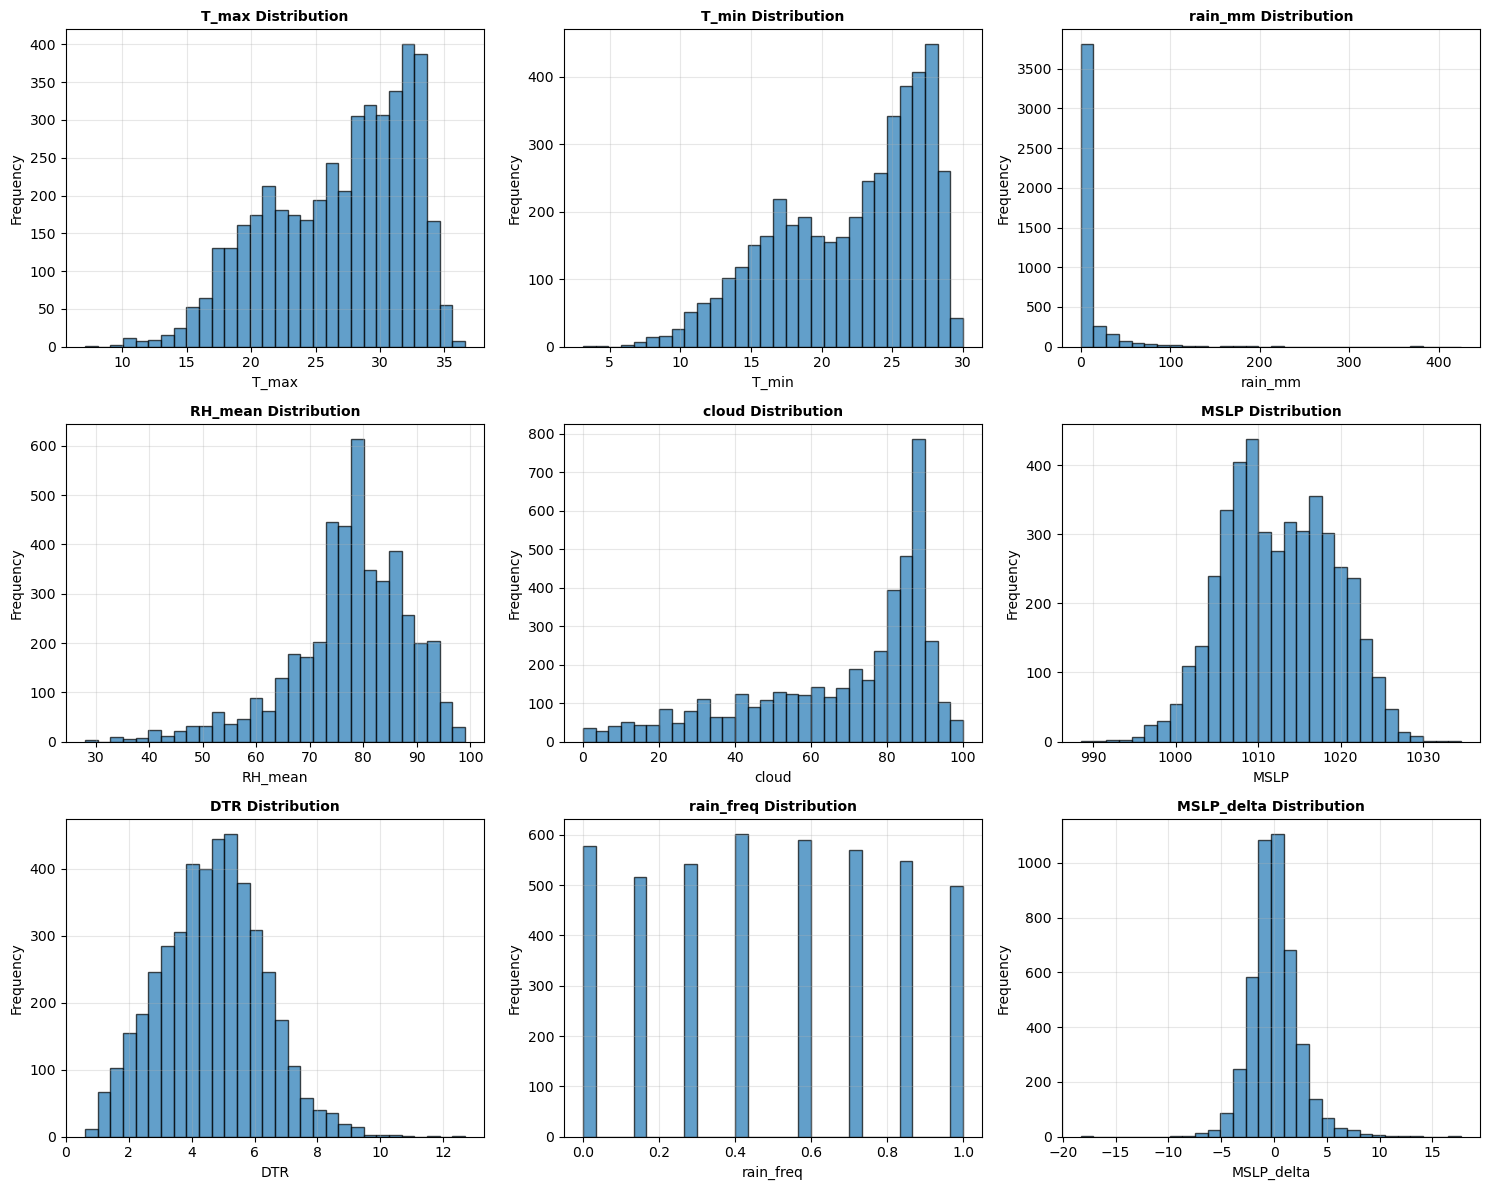

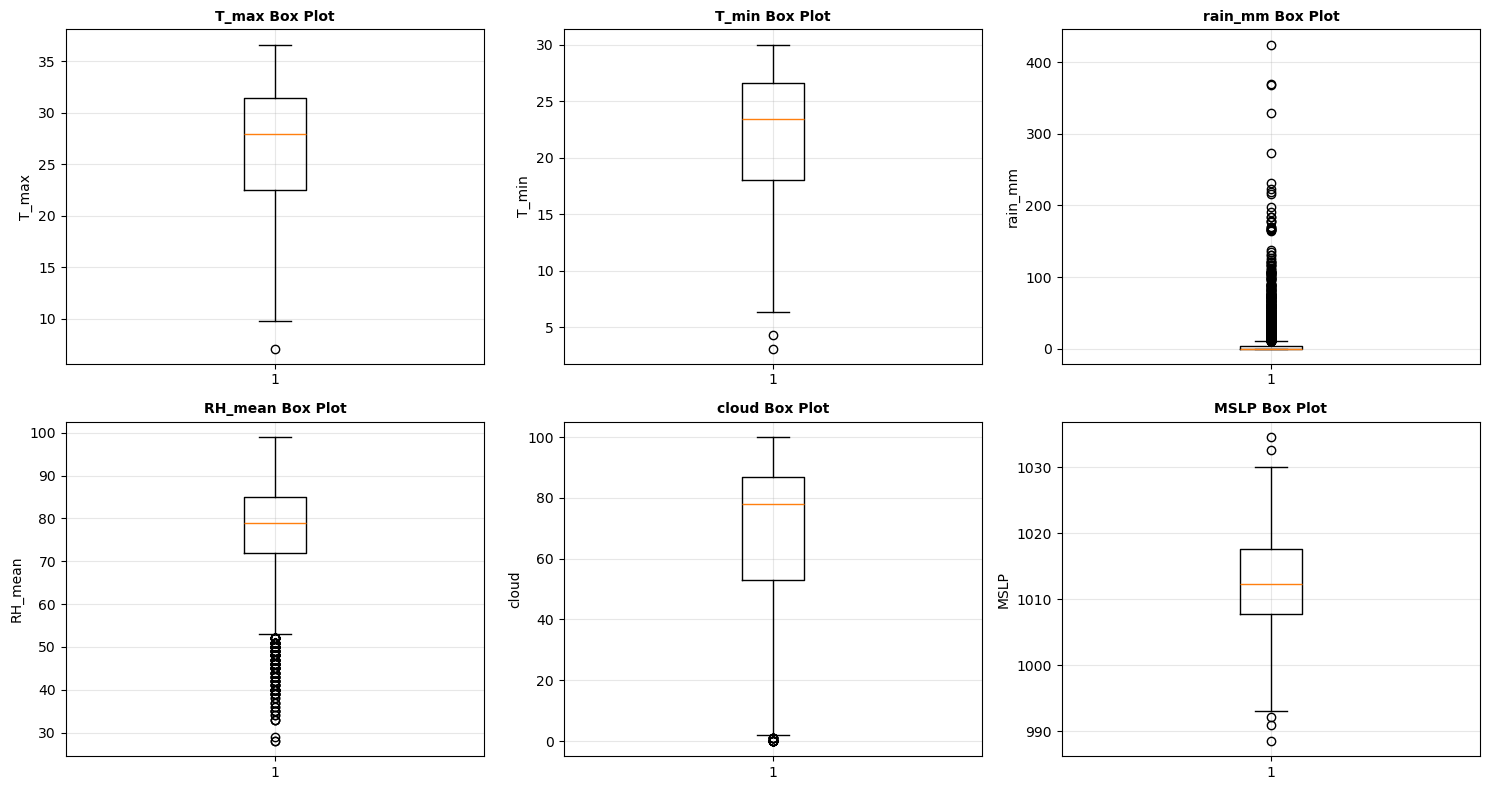

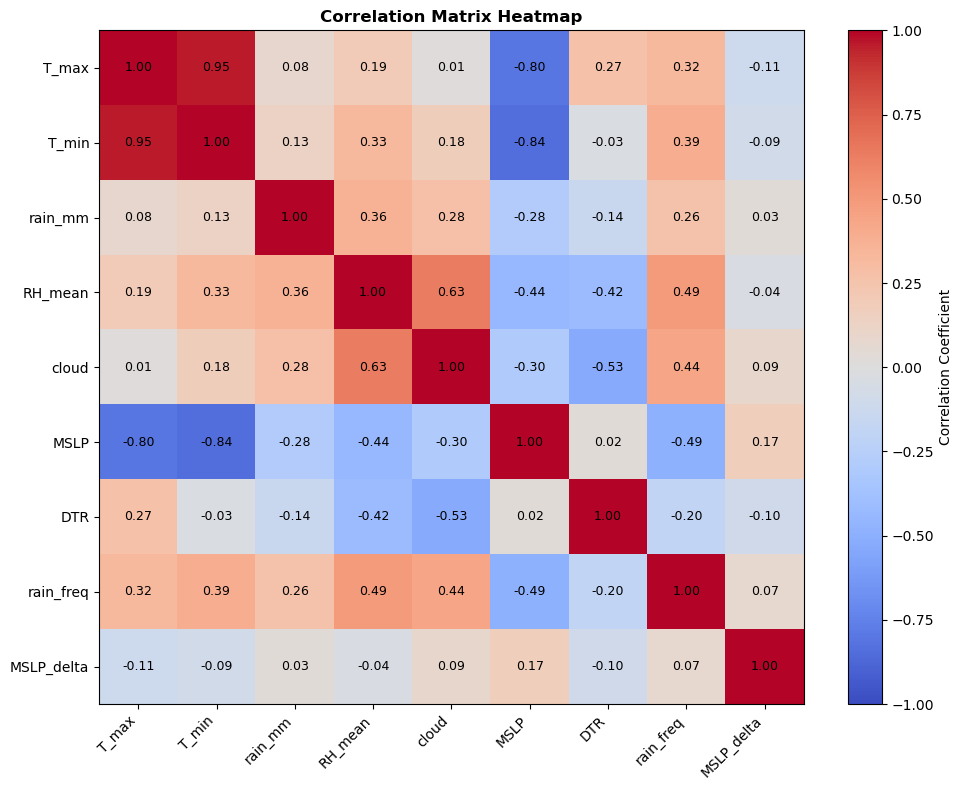


Descriptive statistics and visualization completed.

Time Series Plot - Reveals temporal trends and seasonality


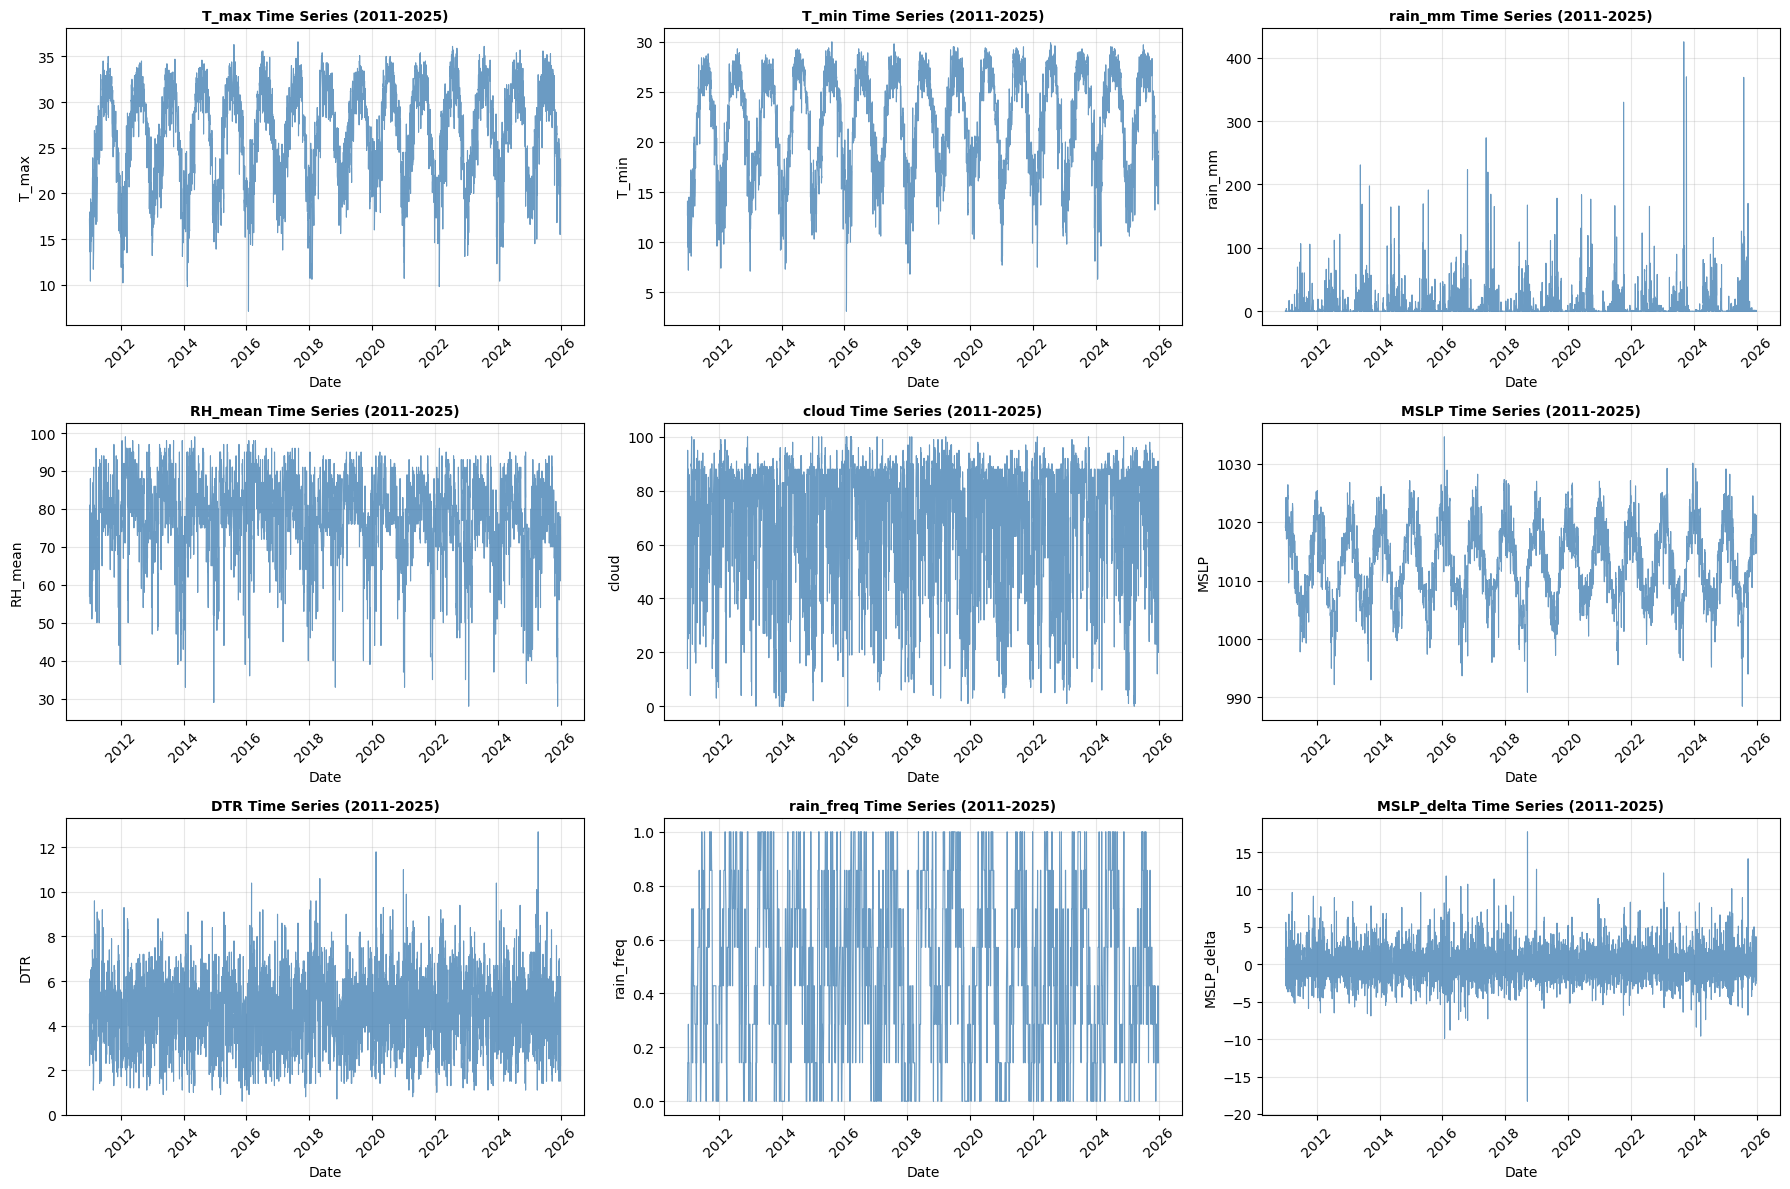


Monthly Average Patterns - Reveals Seasonal Trends


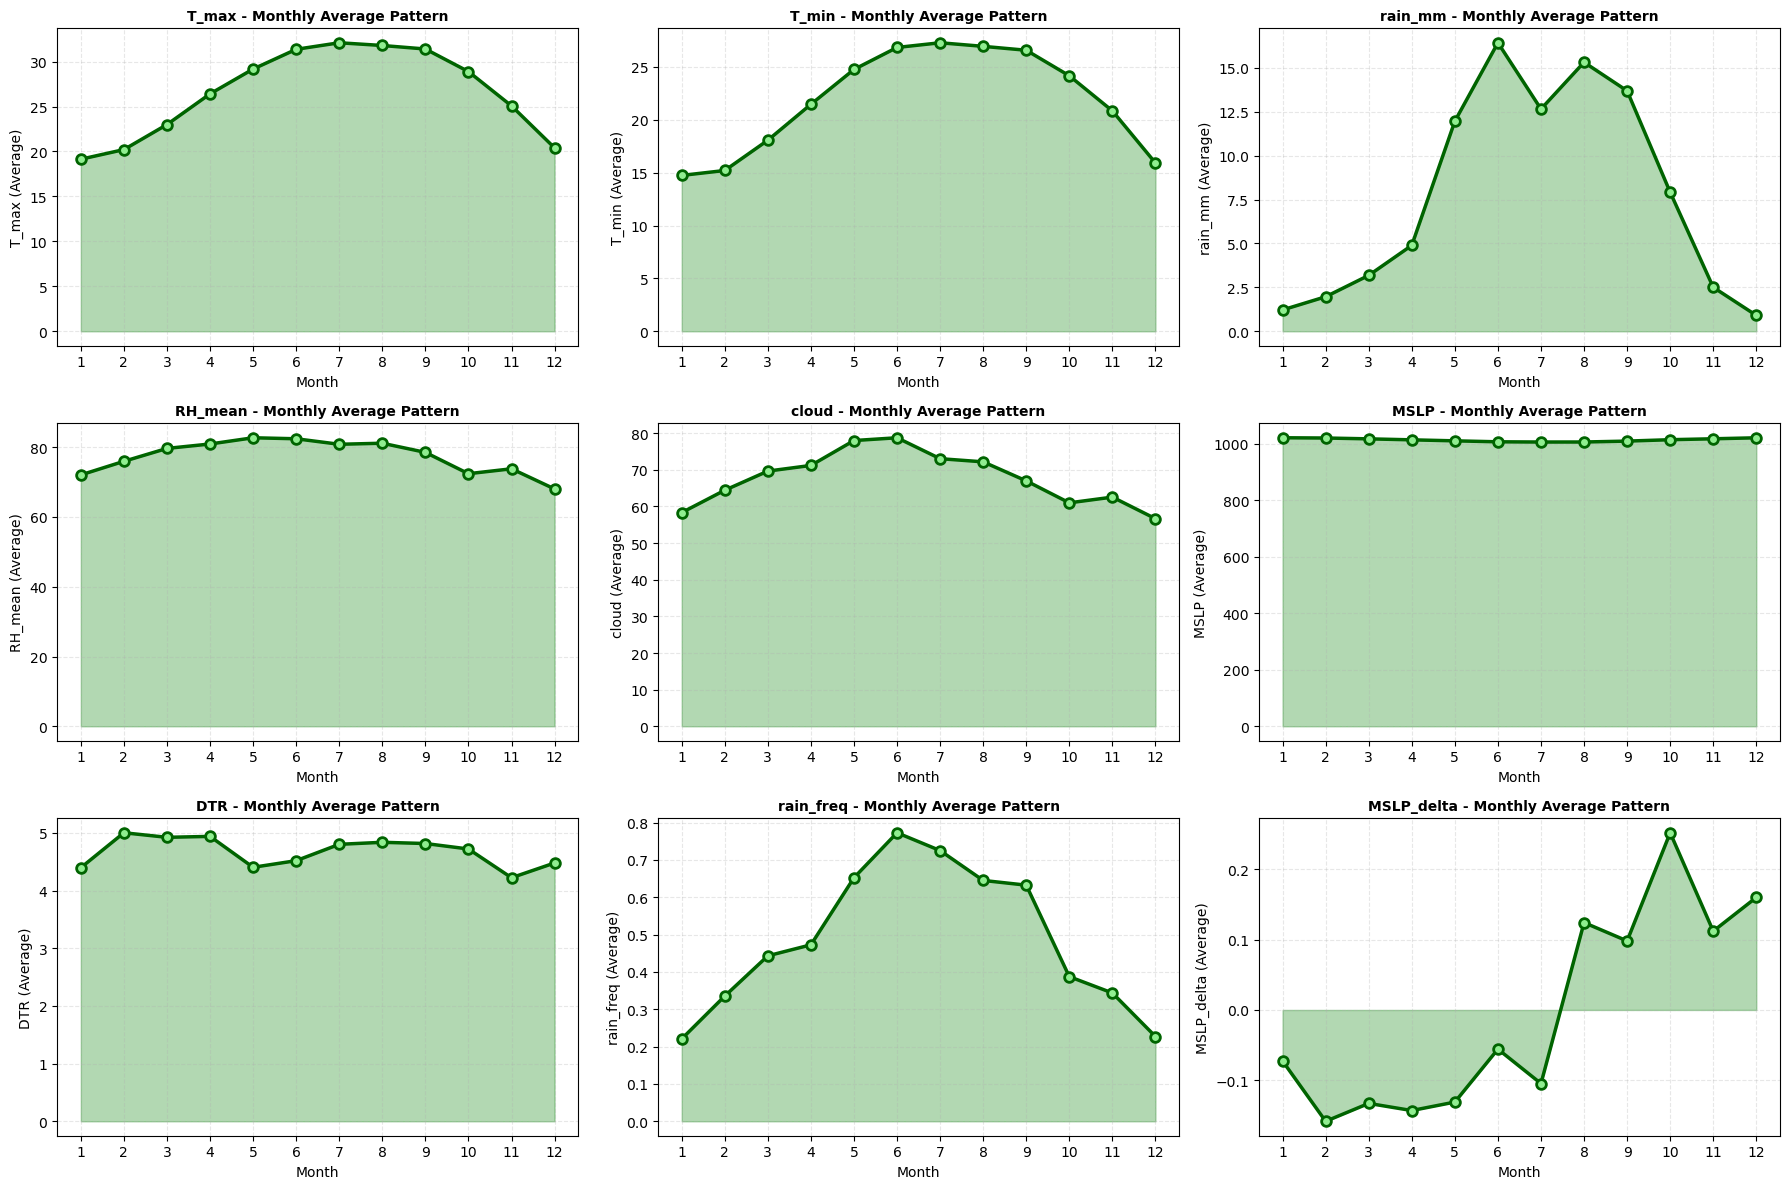


Autocorrelation Function (ACF) - Reveals Temporal Dependencies


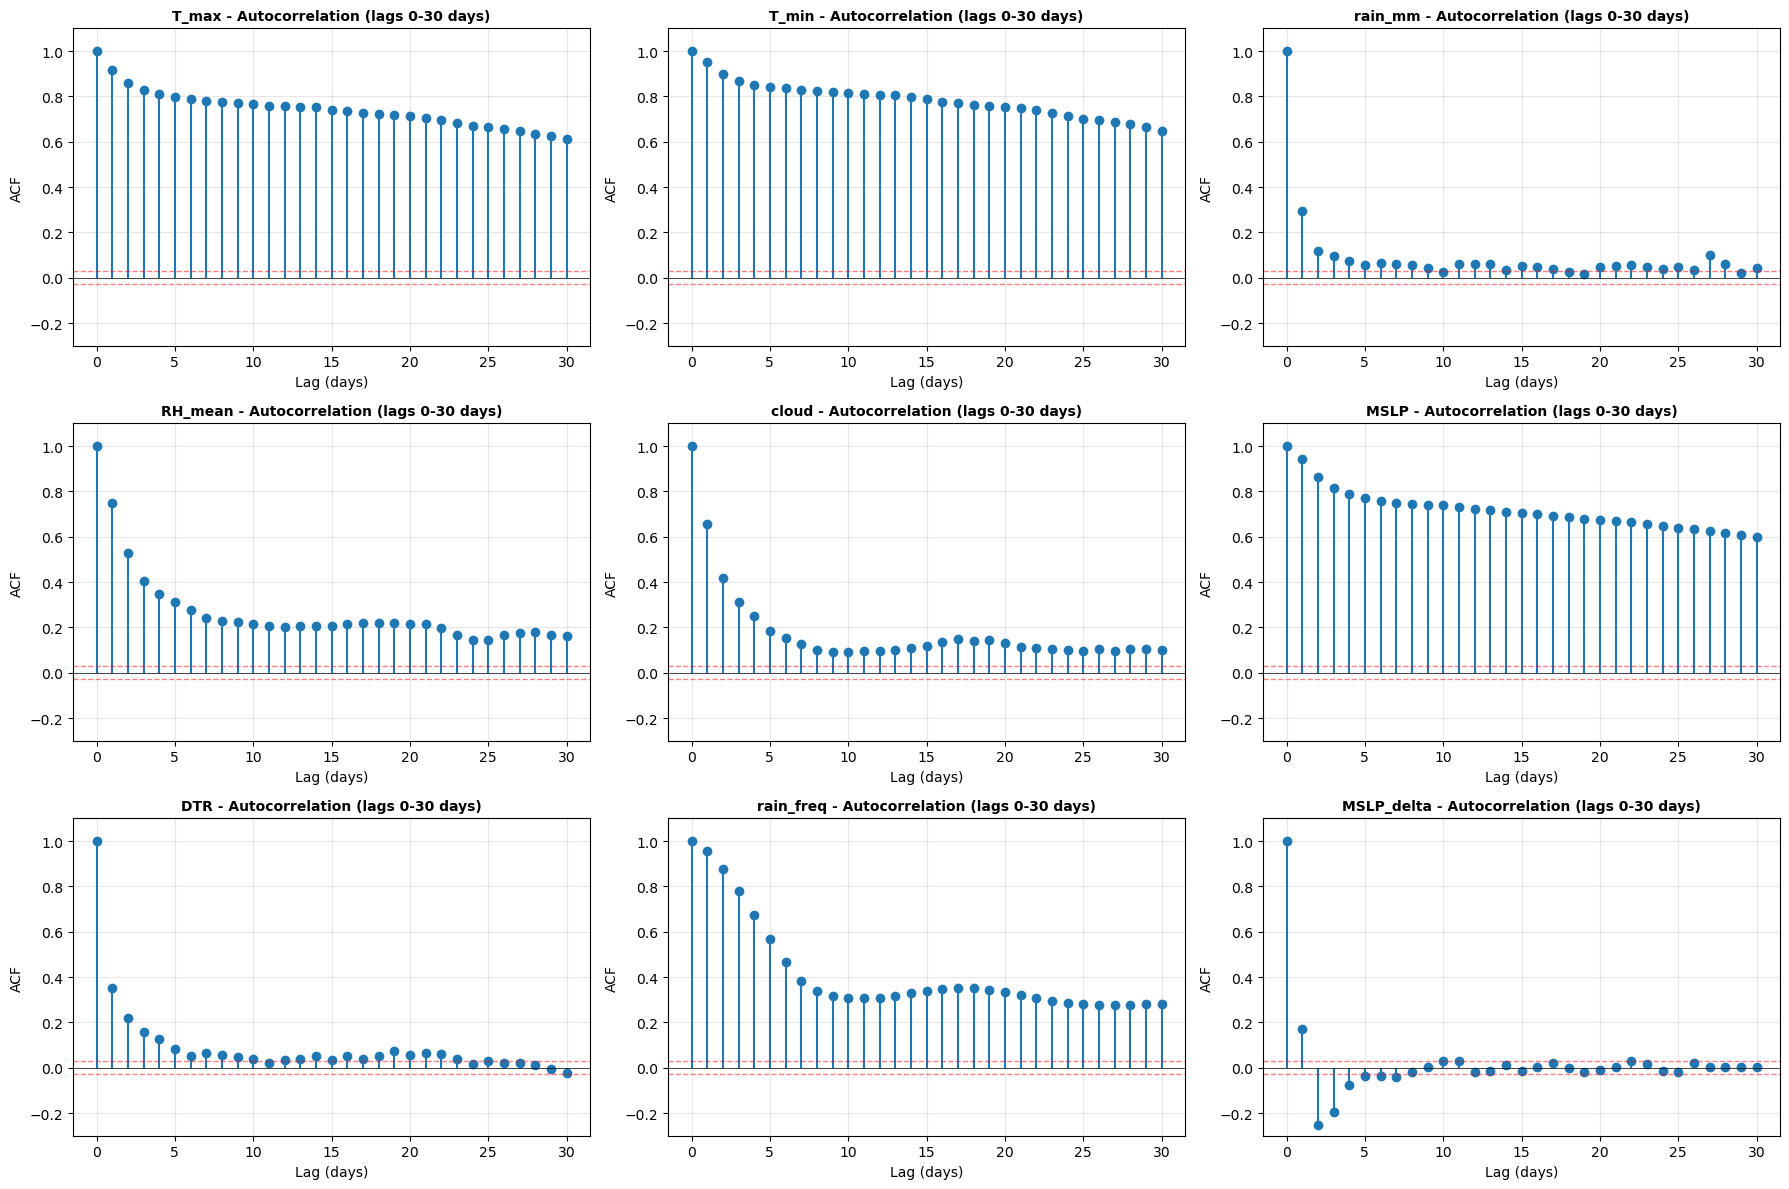


Inter-annual Variability - Reveals Long-term Climate Changes

Yearly average values (showing inter-annual variability):
          T_max      T_min    rain_mm    RH_mean      cloud         MSLP  \
year                                                                       
2011  25.903571  21.043929   5.311429  75.946429  63.596429  1012.508571   
2012  25.894306  21.569395   6.849466  81.174377  73.366548  1011.506050   
2013  25.952508  21.322074   9.522742  77.956522  64.103679  1012.371237   
2014  26.231164  21.667466   9.035274  78.349315  63.746575  1012.777397   
2015  26.769485  22.344485   6.891544  78.768382  67.444853  1012.981250   
2016  26.154639  21.703780  10.401375  80.790378  71.766323  1012.455670   
2017  26.528767  22.036301   8.808562  78.068493  68.075342  1013.113699   
2018  26.876140  22.073333   7.589123  77.122807  69.129825  1012.060702   
2019  27.242492  22.652077   7.655591  78.607029  66.402556  1012.342173   
2020  27.329450  22.514239   7.750809  77.4

In [6]:

# Calculate descriptive statistics and visualize
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Select numeric columns (excluding date)
numeric_cols = dataset_raw.select_dtypes(include=[np.number]).columns.tolist()

# 1. Descriptive statistics table
print("=" * 80)
print("DESCRIPTIVE STATISTICS")
print("=" * 80)
desc_stats = dataset_raw[numeric_cols].describe().T
print(desc_stats)

# 2. Additional statistics (Skewness, Kurtosis, Missing values)
print("\n" + "=" * 80)
print("ADDITIONAL STATISTICS")
print("=" * 80)
additional_stats = pd.DataFrame({
    'Skewness': dataset_raw[numeric_cols].skew(),
    'Kurtosis': dataset_raw[numeric_cols].kurtosis(),
    'Missing_Count': dataset_raw[numeric_cols].isnull().sum(),
    'Missing_%': (dataset_raw[numeric_cols].isnull().sum() / len(dataset_raw) * 100).round(2)
})
print(additional_stats)

# 3. Correlation matrix
print("\n" + "=" * 80)
print("CORRELATION MATRIX")
print("=" * 80)
corr_matrix = dataset_raw[numeric_cols].corr()
print(corr_matrix)

# 4. Distribution histograms
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    if idx < len(axes):
        axes[idx].hist(dataset_raw[col].dropna(), bins=30, alpha=0.7, edgecolor='black')
        axes[idx].set_title(f'{col} Distribution', fontsize=10, fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(alpha=0.3)

for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

# 5. Box plots for outlier detection
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    if idx < len(axes):
        axes[idx].boxplot(dataset_raw[col].dropna())
        axes[idx].set_title(f'{col} Box Plot', fontsize=10, fontweight='bold')
        axes[idx].set_ylabel(col)
        axes[idx].grid(alpha=0.3)

for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

# 6. Correlation heatmap using matplotlib
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)

# Set ticks and labels
ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(corr_matrix.columns)

# Add correlation values as text
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                      ha="center", va="center", color="black", fontsize=9)

ax.set_title('Correlation Matrix Heatmap', fontsize=12, fontweight='bold')
fig.colorbar(im, ax=ax, label='Correlation Coefficient')
plt.tight_layout()
plt.show()

print("\nDescriptive statistics and visualization completed.")

# Convert date to datetime for time series analysis
dataset_raw['date'] = pd.to_datetime(dataset_raw['date'])
dataset_ts = dataset_raw.set_index('date')

# 7. Time series plots - reveal trends and seasonality
print("\nTime Series Plot - Reveals temporal trends and seasonality")
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    axes[idx].plot(dataset_ts[col], linewidth=0.8, alpha=0.8, color='steelblue')
    axes[idx].set_title(f'{col} Time Series (2011-2025)', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Date')
    axes[idx].set_ylabel(col)
    axes[idx].grid(alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=45)

for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

# 8. Monthly average patterns - reveal seasonality explicitly
print("\nMonthly Average Patterns - Reveals Seasonal Trends")
monthly_data = dataset_raw.copy()
monthly_data['month'] = dataset_raw['date'].dt.month
monthly_avg = monthly_data.groupby('month')[numeric_cols].mean()

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    axes[idx].plot(monthly_avg.index, monthly_avg[col], marker='o', linewidth=2.5,
                   markersize=7, color='darkgreen', markerfacecolor='lightgreen', markeredgewidth=2)
    axes[idx].fill_between(monthly_avg.index, monthly_avg[col], alpha=0.3, color='green')
    axes[idx].set_title(f'{col} - Monthly Average Pattern', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Month')
    axes[idx].set_ylabel(f'{col} (Average)')
    axes[idx].set_xticks(range(1, 13))
    axes[idx].grid(alpha=0.3, linestyle='--')

for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

# 9. Autocorrelation analysis - reveal temporal dependencies
print("\nAutocorrelation Function (ACF) - Reveals Temporal Dependencies")
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    ts_data = dataset_ts[col].dropna()
    # Calculate ACF for lags 0-30 days
    acf_vals = [ts_data.autocorr(lag=i) for i in range(31)]

    axes[idx].stem(range(31), acf_vals, basefmt=' ')
    axes[idx].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
    # 95% confidence intervals
    conf_int = 1.96 / np.sqrt(len(ts_data))
    axes[idx].axhline(y=conf_int, color='r', linestyle='--', linewidth=1, alpha=0.5, label='95% CI')
    axes[idx].axhline(y=-conf_int, color='r', linestyle='--', linewidth=1, alpha=0.5)
    axes[idx].set_title(f'{col} - Autocorrelation (lags 0-30 days)', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Lag (days)')
    axes[idx].set_ylabel('ACF')
    axes[idx].grid(alpha=0.3)
    axes[idx].set_ylim([-0.3, 1.1])

for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

# 10. Year-on-year comparison
print("\nInter-annual Variability - Reveals Long-term Climate Changes")
print("=" * 80)
yearly_data = dataset_raw.copy()
yearly_data['year'] = dataset_raw['date'].dt.year
yearly_stats = yearly_data.groupby('year')[numeric_cols].mean()
print("\nYearly average values (showing inter-annual variability):")
print(yearly_stats)


#### 1.2.4 scaling and export final datasets
Output two versions of the dataset: 
- one unscaled for ARIMA, named "data/dataset_for_arima.csv"
- the other normalized for logistic regression and LSTM, named "data/dataset_normalized_lstm.csv"

In [6]:

# Scaling and export final datasets
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Separate date and numeric columns
date_col = dataset_raw['date'].copy()
numeric_cols = dataset_raw.select_dtypes(include=[np.number]).columns.tolist()
numeric_data = dataset_raw[numeric_cols].copy()

# Step 1: Export unscaled version for ARIMA (with date column)
dataset_for_arima = pd.DataFrame({
    'date': date_col,
    **numeric_data
})
dataset_for_arima.to_csv('data/dataset_for_arima.csv', index=False, encoding='utf-8-sig')
print("Exported unscaled dataset for ARIMA: data/dataset_for_arima.csv")
print(f"Shape: {dataset_for_arima.shape}")
print(dataset_for_arima.head())

# Step 2: Scale numeric data using StandardScaler for LSTM and other models
scaler = StandardScaler()
scaled_numeric_data = scaler.fit_transform(numeric_data)
scaled_numeric_data = pd.DataFrame(scaled_numeric_data, columns=numeric_cols)

# Create scaled dataset with date column
dataset_normalized = pd.DataFrame({
    'date': date_col.reset_index(drop=True),
    **scaled_numeric_data
})

# Export scaled version for LSTM
dataset_normalized.to_csv('data/dataset_normalized_lstm.csv', index=False, encoding='utf-8-sig')
print("\n" + "=" * 80)
print("Exported scaled dataset for LSTM: data/dataset_normalized_lstm.csv")
print(f"Shape: {dataset_normalized.shape}")
print(dataset_normalized.head())

# Step 3: Display scaling statistics
print("\n" + "=" * 80)
print("SCALING STATISTICS (StandardScaler)")
print("=" * 80)
scaling_stats = pd.DataFrame({
    'Feature': numeric_cols,
    'Mean': scaler.mean_,
    'Std': scaler.scale_
})
print(scaling_stats)

print("\n" + "=" * 80)
print("Data preprocessing completed successfully!")
print("Output files:")
print("  - data/dataset_for_arima.csv (unscaled)")
print("  - data/dataset_normalized_lstm.csv (scaled with StandardScaler)")


Exported unscaled dataset for ARIMA: data/dataset_for_arima.csv
Shape: (4445, 10)
        date  T_max  T_min  rain_mm  RH_mean  cloud    MSLP  DTR  rain_freq  \
0 2011-01-01   17.2   12.7      0.0     57.0   14.0  1019.1  4.5   0.000000   
1 2011-01-02   16.3   14.1      0.0     65.0   83.0  1019.8  2.2   0.000000   
3 2011-01-04   14.6   12.1      1.2     81.0   95.0  1020.4  2.5   0.142857   
4 2011-01-05   17.9   13.9      0.0     77.0   91.0  1018.6  4.0   0.142857   
6 2011-01-07   13.6    9.5      0.0     63.0   70.0  1024.2  4.1   0.142857   

   MSLP_delta  
0         NaN  
1         0.7  
3         0.6  
4        -1.8  
6         5.6  

Exported scaled dataset for LSTM: data/dataset_normalized_lstm.csv
Shape: (4445, 10)
        date     T_max     T_min   rain_mm   RH_mean     cloud      MSLP  \
0 2011-01-01 -1.767767 -1.804397 -0.336912 -1.861264 -2.246610  0.994335   
1 2011-01-02 -1.933849 -1.536044 -0.336912 -1.132602  0.632106  1.100864   
2 2011-01-04 -2.247559 -1.919405 

## 2. Model training and evaluation

**Description.** This section trains and evaluates three forecasting models on the same temporal split. Each model is fit on the training set; validation is used for early stopping (LSTM) or inspection; final performance is reported on the held-out test set (2023–2025), which is never used during training.

**Models.**
- **Logistic Regression**: binary classification (rain yes/no) using lag and rolling features from the ARIMA-scale dataset.
- **LSTM**: multivariate sequence model (normalized inputs) for next-day **T_max**, **T_min**, and **rain** (separate heads). Uses 30-day windows; validation loss for early stopping.
- **SARIMA**: univariate time series (T_max, T_min, rain_mm) with seasonal order 7; fit on train+validation, then forecast the test length for evaluation.

**Analysis strategy.**
- **Data split**: 12 years (2011–2022) for train+validation, 3 years (2023–2025) for test. Within 2011–2022: train 2011–2020, validation 2021–2022. All models use the same date cutoffs so comparisons are fair.
- **Data preparation**: Logistic and SARIMA use the original-scale (ARIMA) dataset; LSTM uses normalized sequences. Targets and features are aligned by date (e.g. sequence end date for LSTM).
- **Training**: Models are fit only on the training set. We do not tune hyperparameters on the test set; validation is used only for monitoring (e.g. LSTM early stopping).
- **Evaluation**: Test-set metrics are computed once after training and used in Section 3 for model comparison and selection.

### 2.1 Data split and preparation

In [7]:
import sys
sys.path.insert(0, ".")
import numpy as np
import pandas as pd
from utils.data_utils import load_arima_data, load_normalized_data, split_train_valid_test, split_Xy_by_date
from utils.model_logistic import prepare_logistic_data, train_logistic, predict_logistic, predict_logistic_proba
from utils.model_lstm import build_sequences, train_lstm, predict_lstm
from utils.model_sarima import check_stationarity, fit_and_forecast_test
from utils.metrics import regression_metrics, classification_metrics
from utils.visualization import (
    plot_predictions_vs_actual,
    plot_model_comparison,
    plot_future_forecast,
    plot_rain_classification_diagnostic,
)

DATA_DIR = "data"
VALID_START = "2021-01-01"
TEST_START = "2023-01-01"

# Load datasets
df_arima = load_arima_data(DATA_DIR)
df_norm = load_normalized_data(DATA_DIR)

# Drop first row if MSLP_delta is NaN (no lag value)
df_arima = df_arima.dropna(subset=["MSLP_delta"]).reset_index(drop=True)
df_norm = df_norm.dropna(subset=["MSLP_delta"]).reset_index(drop=True)

# Split by date (same split for all models)
train_a, valid_a, test_a = split_train_valid_test(df_arima, test_start=TEST_START, valid_start=VALID_START)
train_n, valid_n, test_n = split_train_valid_test(df_norm, test_start=TEST_START, valid_start=VALID_START)

print("Split sizes (ARIMA dataset):", f"train={len(train_a)}, valid={len(valid_a)}, test={len(test_a)}")
print("Date ranges: train", train_a["date"].min(), "to", train_a["date"].max(),
      "| test", test_a["date"].min(), "to", test_a["date"].max())

# Prepare Logistic Regression: full-dataset features then split by date
X_lr, y_lr, lr_feature_names = prepare_logistic_data(df_arima, lags=[1, 2, 3, 7], window=7)
X_lr_train, y_lr_train, X_lr_valid, y_lr_valid, X_lr_test, y_lr_test = split_Xy_by_date(
    X_lr, y_lr, valid_start=VALID_START, test_start=TEST_START
)
print("\nLogistic features: train=%d, valid=%d, test=%d" % (len(X_lr_train), len(X_lr_valid), len(X_lr_test)))

# Prepare LSTM sequences (T_max): use normalized data, seq_len=30
SEQ_LEN = 30
X_seq_full, y_seq_full, dates_seq = build_sequences(df_norm, target_col="T_max", seq_len=SEQ_LEN)
# Align with date split
valid_start_ts = pd.Timestamp(VALID_START)
test_start_ts = pd.Timestamp(TEST_START)
dates_seq = pd.to_datetime(dates_seq)
train_idx = dates_seq < valid_start_ts
valid_idx = (dates_seq >= valid_start_ts) & (dates_seq < test_start_ts)
test_idx = dates_seq >= test_start_ts
X_lstm_train, y_lstm_train = X_seq_full[train_idx], y_seq_full[train_idx]
X_lstm_valid, y_lstm_valid = X_seq_full[valid_idx], y_seq_full[valid_idx]
X_lstm_test, y_lstm_test = X_seq_full[test_idx], y_seq_full[test_idx]
dates_lstm_test = dates_seq[test_idx]
print("LSTM sequences: train=%d, valid=%d, test=%d" % (len(X_lstm_train), len(X_lstm_valid), len(X_lstm_test)))

# SARIMA: univariate T_max and T_min series (train+valid for fitting, test for evaluation)
train_valid_arima = pd.concat([train_a, valid_a], ignore_index=True)
sarima_train_series = train_valid_arima.set_index("date")["T_max"]
sarima_test_series = test_a.set_index("date")["T_max"]
sarima_train_tmin_series = train_valid_arima.set_index("date")["T_min"]
sarima_test_tmin_series = test_a.set_index("date")["T_min"]
sarima_train_rain_series = train_valid_arima.set_index("date")["rain_mm"]
sarima_test_rain_series = test_a.set_index("date")["rain_mm"]
print("SARIMA: train+valid len=%d, test len=%d" % (len(sarima_train_series), len(sarima_test_series)))

# LSTM sequences for T_min (same date split)
X_seq_full_tmin, y_seq_full_tmin, _ = build_sequences(df_norm, target_col="T_min", seq_len=SEQ_LEN)
X_lstm_train_tmin = X_seq_full_tmin[train_idx]
y_lstm_train_tmin = y_seq_full_tmin[train_idx]
X_lstm_valid_tmin = X_seq_full_tmin[valid_idx]
y_lstm_valid_tmin = y_seq_full_tmin[valid_idx]
X_lstm_test_tmin = X_seq_full_tmin[test_idx]
y_lstm_test_tmin = y_seq_full_tmin[test_idx]
print("LSTM T_min: train=%d, valid=%d, test=%d" % (len(X_lstm_train_tmin), len(X_lstm_valid_tmin), len(X_lstm_test_tmin)))

# LSTM sequences for rain (binary: rain next day yes/no)
df_norm["rain_binary"] = (df_norm["rain_mm"] > 0).astype(int)
X_seq_full_rain, y_seq_full_rain, _ = build_sequences(df_norm, target_col="rain_binary", seq_len=SEQ_LEN)
X_lstm_train_rain = X_seq_full_rain[train_idx]
y_lstm_train_rain = y_seq_full_rain[train_idx].astype(int)
X_lstm_valid_rain = X_seq_full_rain[valid_idx]
y_lstm_valid_rain = y_seq_full_rain[valid_idx].astype(int)
X_lstm_test_rain = X_seq_full_rain[test_idx]
y_lstm_test_rain = y_seq_full_rain[test_idx].astype(int)
print("LSTM rain: train=%d, valid=%d, test=%d" % (len(X_lstm_train_rain), len(X_lstm_valid_rain), len(X_lstm_test_rain)))

Split sizes (ARIMA dataset): train=2913, valid=621, test=910
Date ranges: train 2011-01-02 00:00:00 to 2020-12-31 00:00:00 | test 2023-01-01 00:00:00 to 2025-12-31 00:00:00

Logistic features: train=2906, valid=621, test=910
LSTM sequences: train=2883, valid=621, test=910
SARIMA: train+valid len=3534, test len=910
LSTM T_min: train=2883, valid=621, test=910
LSTM rain: train=2883, valid=621, test=910


### 2.2 Logistic Regression (rain classification)

In [8]:
# Train Logistic Regression
lr_model, lr_scaler = train_logistic(X_lr_train, y_lr_train, lr_feature_names, C=1.0, max_iter=1000)

# Predict on validation and test
y_lr_valid_pred = predict_logistic(lr_model, lr_scaler, X_lr_valid, lr_feature_names)
y_lr_test_pred = predict_logistic(lr_model, lr_scaler, X_lr_test, lr_feature_names)
y_lr_valid_score = predict_logistic_proba(lr_model, lr_scaler, X_lr_valid, lr_feature_names)
y_lr_test_score = predict_logistic_proba(lr_model, lr_scaler, X_lr_test, lr_feature_names)

# Evaluate (classification metrics)
lr_metrics_valid = classification_metrics(y_lr_valid.values, y_lr_valid_pred)
lr_metrics_test = classification_metrics(y_lr_test.values, y_lr_test_pred)
print("Logistic Regression — Validation:", lr_metrics_valid)
print("Logistic Regression — Test:      ", lr_metrics_test)

Logistic Regression — Validation: {'Accuracy': 0.784219001610306, 'F1': 0.7649122807017543}
Logistic Regression — Test:       {'Accuracy': 0.7604395604395604, 'F1': 0.7650862068965517}


### 2.3 LSTM (T_max regression)

In [9]:
# Train LSTM (requires TensorFlow)
try:
    lstm_model = train_lstm(
        X_lstm_train, y_lstm_train,
        X_val=X_lstm_valid, y_val=y_lstm_valid,
        units=64, dropout=0.2, epochs=50, batch_size=32, patience=10, verbose=1
    )
    y_lstm_valid_pred = predict_lstm(lstm_model, X_lstm_valid)
    y_lstm_test_pred = predict_lstm(lstm_model, X_lstm_test)
    lstm_metrics_valid = regression_metrics(y_lstm_valid, y_lstm_valid_pred)
    lstm_metrics_test = regression_metrics(y_lstm_test, y_lstm_test_pred)
    print("LSTM — Validation:", lstm_metrics_valid)
    print("LSTM — Test:     ", lstm_metrics_test)
    HAS_LSTM = True
except ImportError as e:
    print("LSTM skipped (TensorFlow not installed):", e)
    HAS_LSTM = False
    lstm_metrics_valid = lstm_metrics_test = None
    y_lstm_test_pred = None
    dates_lstm_test = None

Epoch 1/50


/Users/rain/miniconda3/envs/pytorch_env/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.4258 - mae: 0.5023 - val_loss: 0.2255 - val_mae: 0.3772
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2103 - mae: 0.3556 - val_loss: 0.2040 - val_mae: 0.3517
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1921 - mae: 0.3420 - val_loss: 0.1915 - val_mae: 0.3427
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1803 - mae: 0.3356 - val_loss: 0.1811 - val_mae: 0.3332
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1692 - mae: 0.3258 - val_loss: 0.1686 - val_mae: 0.3247
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1634 - mae: 0.3221 - val_loss: 0.1613 - val_mae: 0.3145
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1595 - mae: 0.3105 - val_loss: 0.1556 - val_mae: 0.3074
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1400 - mae: 0.2949 - val_loss: 0.1520 - val_mae: 0.3001
Epoch 9/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1485 - mae: 0.2984 - v

### 2.3b LSTM (T_min regression)

Train LSTM to predict next-day **T_min** (lowest temperature) for comparison with SARIMA.

In [10]:
# Train LSTM for T_min (requires TensorFlow)
try:
    lstm_model_tmin = train_lstm(
        X_lstm_train_tmin, y_lstm_train_tmin,
        X_val=X_lstm_valid_tmin, y_val=y_lstm_valid_tmin,
        units=64, dropout=0.2, epochs=50, batch_size=32, patience=10, verbose=1
    )
    y_lstm_tmin_test_pred = predict_lstm(lstm_model_tmin, X_lstm_test_tmin)
    lstm_tmin_metrics_test = regression_metrics(y_lstm_test_tmin, y_lstm_tmin_test_pred)
    print("LSTM T_min — Test:", lstm_tmin_metrics_test)
    HAS_LSTM_TMIN = True
except ImportError as e:
    print("LSTM T_min skipped (TensorFlow not installed):", e)
    HAS_LSTM_TMIN = False
    lstm_tmin_metrics_test = None
    y_lstm_tmin_test_pred = None

Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2638 - mae: 0.3864 - val_loss: 0.1549 - val_mae: 0.3058
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1482 - mae: 0.2984 - val_loss: 0.1447 - val_mae: 0.2856
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1331 - mae: 0.2817 - val_loss: 0.1329 - val_mae: 0.2688
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1224 - mae: 0.2682 - val_loss: 0.1209 - val_mae: 0.2630
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1170 - mae: 0.2647 - val_loss: 0.1251 - val_mae: 0.2629
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1150 - mae: 0.2556 - val_loss: 0.1110 - val_mae: 0.2491
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1135 - mae: 0.2594 - val_loss: 0.1092 - val_mae: 0.2467
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1059 - mae: 0.2484 - val_loss: 0.1064 - val_mae: 0.2440
Epoch 9/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1078 - mae: 

### 2.3c LSTM (rain classification)

Train LSTM to predict next-day **rain yes/no** (binary) for comparison with Logistic Regression and SARIMA.

In [11]:
# Train LSTM for rain classification (requires TensorFlow)
try:
    lstm_model_rain = train_lstm(
        X_lstm_train_rain, y_lstm_train_rain,
        X_val=X_lstm_valid_rain, y_val=y_lstm_valid_rain,
        units=64, dropout=0.2, epochs=50, batch_size=32, patience=10, verbose=1,
        classification=True
    )
    y_lstm_rain_test_pred = predict_lstm(lstm_model_rain, X_lstm_test_rain, classification=True)
    lstm_rain_metrics_test = classification_metrics(y_lstm_test_rain, y_lstm_rain_test_pred)
    print("LSTM rain — Test:", lstm_rain_metrics_test)
    HAS_LSTM_RAIN = True
except ImportError as e:
    print("LSTM rain skipped (TensorFlow not installed):", e)
    HAS_LSTM_RAIN = False
    lstm_rain_metrics_test = None
    y_lstm_rain_test_pred = None

Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6932 - loss: 0.5669 - val_accuracy: 0.8261 - val_loss: 0.4047
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7839 - loss: 0.4704 - val_accuracy: 0.8261 - val_loss: 0.3835
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7940 - loss: 0.4350 - val_accuracy: 0.8325 - val_loss: 0.3802
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7872 - loss: 0.4395 - val_accuracy: 0.8406 - val_loss: 0.3719
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7949 - loss: 0.4307 - val_accuracy: 0.8357 - val_loss: 0.3590
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7872 - loss: 0.4359 - val_accuracy: 0.8406 - val_loss: 0.3584
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8047 - loss: 0.4119 - val_accuracy: 0.8422 - val_loss: 0.3503
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8017 - loss: 0.4016 - val_accuracy: 0.8438 - val_loss:

### 2.4 SARIMA (T_max, T_min, rain)

Fit SARIMA on univariate series (train+valid) and forecast the test length. We fit **separate** models for T_max, T_min, and rain_mm (rain_mm is then thresholded to binary for classification). Stationarity is addressed via the integrated order (d, D); seasonal period is 7 (weekly) for daily data.

In [12]:
# Optional: check stationarity of T_max (training series)
adf_result = check_stationarity(sarima_train_series, "T_max")
print("ADF test on T_max (train):", adf_result)

# Fit SARIMA on train+valid and forecast test length
SARIMA_ORDER = (1, 0, 1)
SARIMA_SEASONAL = (1, 0, 1, 7)
y_sarima_test_pred = fit_and_forecast_test(
    sarima_train_series, test_len=len(sarima_test_series),
    order=SARIMA_ORDER, seasonal_order=SARIMA_SEASONAL
)
# Align: test actuals
y_sarima_test_actual = sarima_test_series.values
# Trim if forecast is shorter (e.g. due to NaN)
n_test = min(len(y_sarima_test_actual), len(y_sarima_test_pred))
y_sarima_test_actual = y_sarima_test_actual[:n_test]
y_sarima_test_pred = y_sarima_test_pred[:n_test]
sarima_metrics_test = regression_metrics(y_sarima_test_actual, y_sarima_test_pred)
print("SARIMA T_max — Test:", sarima_metrics_test)
dates_sarima_test = sarima_test_series.index[:n_test]

# SARIMA for T_min (lowest temp)
y_sarima_tmin_pred = fit_and_forecast_test(
    sarima_train_tmin_series, test_len=len(sarima_test_tmin_series),
    order=SARIMA_ORDER, seasonal_order=SARIMA_SEASONAL
)
y_sarima_tmin_actual = sarima_test_tmin_series.values
n_tmin = min(len(y_sarima_tmin_actual), len(y_sarima_tmin_pred))
y_sarima_tmin_actual = y_sarima_tmin_actual[:n_tmin]
y_sarima_tmin_pred = np.array(y_sarima_tmin_pred[:n_tmin])
sarima_tmin_metrics_test = regression_metrics(y_sarima_tmin_actual, y_sarima_tmin_pred)
print("SARIMA T_min — Test:", sarima_tmin_metrics_test)

# SARIMA for rain: forecast rain_mm then threshold to binary
y_sarima_rain_pred_raw = fit_and_forecast_test(
    sarima_train_rain_series, test_len=len(sarima_test_rain_series),
    order=SARIMA_ORDER, seasonal_order=SARIMA_SEASONAL
)
y_sarima_rain_actual = (sarima_test_rain_series.values > 0).astype(int)
n_rain = min(len(y_sarima_rain_actual), len(y_sarima_rain_pred_raw))
y_sarima_rain_actual = y_sarima_rain_actual[:n_rain]
y_sarima_rain_pred = (np.array(y_sarima_rain_pred_raw[:n_rain]) > 0).astype(int)
sarima_rain_metrics_test = classification_metrics(y_sarima_rain_actual, y_sarima_rain_pred)
print("SARIMA rain — Test:", sarima_rain_metrics_test)

ADF test on T_max (train): {'adf_stat': -4.517072800174171, 'pvalue': 0.00018313412102333512, 'stationary': True}
SARIMA T_max — Test: {'MSE': 26.23007716196775, 'RMSE': 5.121530744022508, 'MAE': 4.3781509807712595, 'MAPE': 17.116449929884244}
SARIMA T_min — Test: {'MSE': 25.29913391235111, 'RMSE': 5.029824441504008, 'MAE': 4.412180092094724, 'MAPE': 21.8936704625443}
SARIMA rain — Test: {'Accuracy': 0.48131868131868133, 'F1': 0.6498516320474778}


## 3. Model comparison and evaluation

**Description.** This section aggregates test-set metrics for all models, compares them **per target** (T_max, T_min, rain), and selects one best model per target. Those choices are then used for prediction plots and (optionally) future forecasts.

**What we compare.**
- **T_max** (regression): LSTM vs SARIMA — metrics: MSE, RMSE, MAE, MAPE.
- **T_min** (regression): LSTM vs SARIMA — same regression metrics.
- **Rain** (classification): Logistic Regression vs LSTM vs SARIMA — metrics: Accuracy, F1.

**What is MAPE?** Mean Absolute Percentage Error = average of |actual − predicted| / |actual| × 100. It can explode when actual values are close to zero or on a small scale (e.g. **normalized** targets). The LSTM uses normalized data, so its MAPE is often extreme even when errors are small; SARIMA uses the original scale (°C). We **do not use MAPE** to choose the best model.

**Analysis strategy (how we choose the best model).**
- **T_max and T_min**: Best model = **lowest RMSE** on the test set. RMSE is in the same units as the target and does not suffer from MAPE's instability, so LSTM can have a much higher MAPE than SARIMA but still be chosen if it has the lower RMSE.
- **Rain**: Best model = **highest F1** on the test set. F1 balances precision and recall and is more informative than accuracy when rain/no-rain classes are imbalanced.

We then use the best-performing model per target for the prediction vs actual plots and any future forecast.

In [13]:
# Summary table: regression (T_max) — LSTM vs SARIMA on test set
print("Regression (T_max) — Test set metrics")
print("-" * 50)
results_reg = {}
if HAS_LSTM and lstm_metrics_test:
    results_reg["LSTM"] = lstm_metrics_test
    for k, v in lstm_metrics_test.items():
        print(f"  LSTM   {k}: {v:.4f}")
results_reg["SARIMA"] = sarima_metrics_test
for k, v in sarima_metrics_test.items():
    print(f"  SARIMA {k}: {v:.4f}")

# Regression (T_min — lowest temp) — LSTM vs SARIMA
try: _ = HAS_LSTM_TMIN
except NameError: HAS_LSTM_TMIN = False
print("\nRegression (T_min) — Test set metrics")
print("-" * 50)
results_reg_tmin = {}
if HAS_LSTM_TMIN and lstm_tmin_metrics_test:
    results_reg_tmin["LSTM"] = lstm_tmin_metrics_test
    for k, v in lstm_tmin_metrics_test.items():
        print(f"  LSTM   {k}: {v:.4f}")
results_reg_tmin["SARIMA"] = sarima_tmin_metrics_test
for k, v in sarima_tmin_metrics_test.items():
    print(f"  SARIMA {k}: {v:.4f}")

# Classification (rain) — Logistic, LSTM, SARIMA on test set
try: _ = HAS_LSTM_RAIN
except NameError: HAS_LSTM_RAIN = False
print("\nClassification (rain) — Test set metrics")
print("-" * 50)
results_clf = {"Logistic Regression": lr_metrics_test}
for k, v in lr_metrics_test.items():
    print(f"  Logistic {k}: {v:.4f}")
if HAS_LSTM_RAIN and lstm_rain_metrics_test:
    results_clf["LSTM"] = lstm_rain_metrics_test
    for k, v in lstm_rain_metrics_test.items():
        print(f"  LSTM    {k}: {v:.4f}")
results_clf["SARIMA"] = sarima_rain_metrics_test
for k, v in sarima_rain_metrics_test.items():
    print(f"  SARIMA  {k}: {v:.4f}")

# Best models
best_reg_name = min(results_reg, key=lambda m: results_reg[m]["RMSE"])
print("\nBest regression model T_max (by RMSE):", best_reg_name)
if results_reg_tmin:
    best_reg_tmin_name = min(results_reg_tmin, key=lambda m: results_reg_tmin[m]["RMSE"])
    print("Best regression model T_min (by RMSE):", best_reg_tmin_name)
else:
    best_reg_tmin_name = "SARIMA"
    print("Best regression model T_min: defaulting to", best_reg_tmin_name, "(empty T_min results)")
best_clf_name = max(results_clf, key=lambda m: results_clf[m]["F1"])
print("Best classification model rain (by F1):", best_clf_name)

# Summary: compare T_max, T_min, and rain between models
print("\n" + "=" * 50)
print("COMPARISON SUMMARY")
print("=" * 50)
print("  T_max (regression):  ", best_reg_name, "(LSTM vs SARIMA)")
print("  T_min (regression):  ", best_reg_tmin_name, "(LSTM vs SARIMA)")
print("  Rain (classification):", best_clf_name, "(Logistic vs LSTM vs SARIMA)")
print("=" * 50)

Regression (T_max) — Test set metrics
--------------------------------------------------
  LSTM   MSE: 0.1320
  LSTM   RMSE: 0.3633
  LSTM   MAE: 0.2749
  LSTM   MAPE: 131.5924
  SARIMA MSE: 26.2301
  SARIMA RMSE: 5.1215
  SARIMA MAE: 4.3782
  SARIMA MAPE: 17.1164

Regression (T_min) — Test set metrics
--------------------------------------------------
  LSTM   MSE: 0.0932
  LSTM   RMSE: 0.3052
  LSTM   MAE: 0.2207
  LSTM   MAPE: 101.1456
  SARIMA MSE: 25.2991
  SARIMA RMSE: 5.0298
  SARIMA MAE: 4.4122
  SARIMA MAPE: 21.8937

Classification (rain) — Test set metrics
--------------------------------------------------
  Logistic Accuracy: 0.7604
  Logistic F1: 0.7651
  LSTM    Accuracy: 0.8297
  LSTM    F1: 0.3460
  SARIMA  Accuracy: 0.4813
  SARIMA  F1: 0.6499

Best regression model T_max (by RMSE): LSTM
Best regression model T_min (by RMSE): LSTM
Best classification model rain (by F1): Logistic Regression

COMPARISON SUMMARY
  T_max (regression):   LSTM (LSTM vs SARIMA)
  T_min (regres

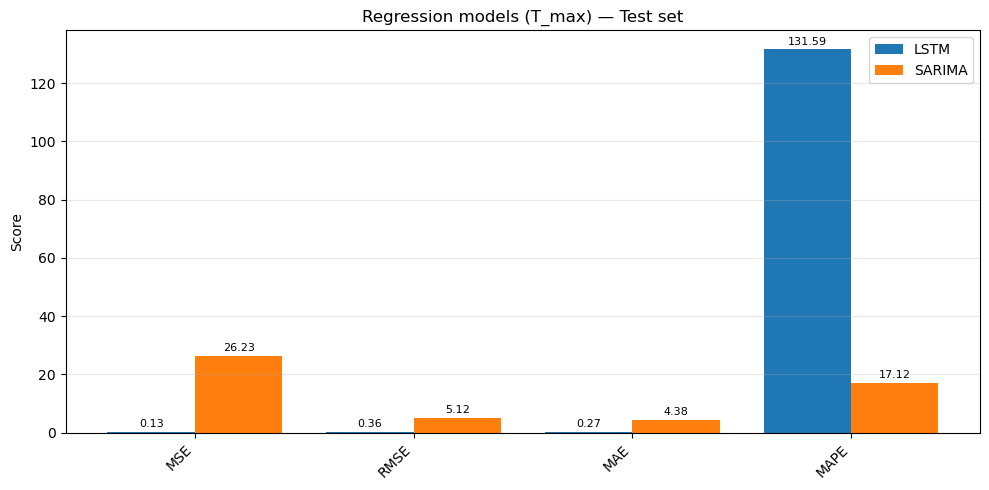

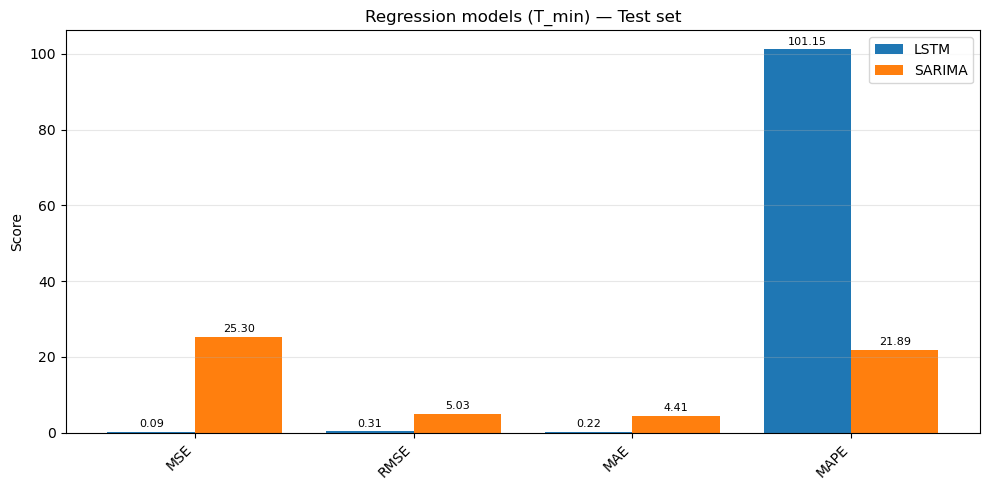

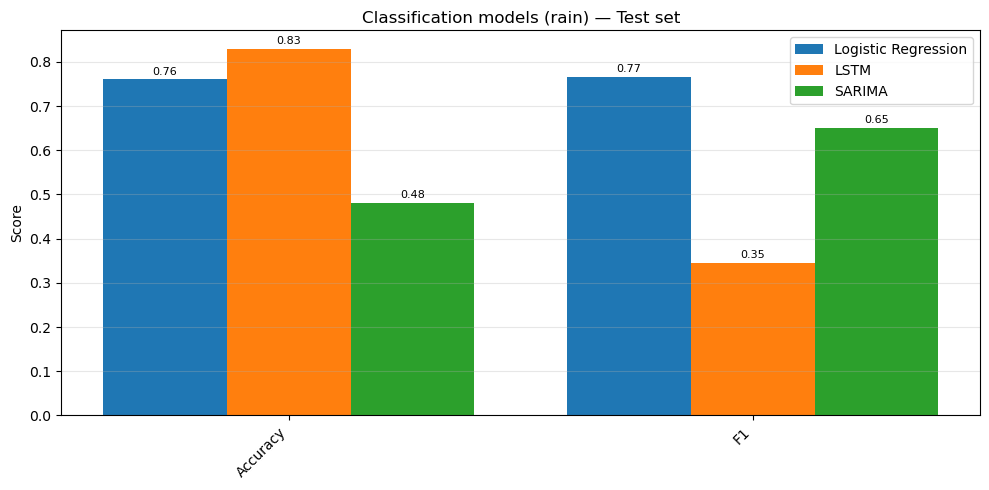

In [14]:
# Compare regression models with bar charts
plot_model_comparison(
    results_reg,
    metric_names=["MSE", "RMSE", "MAE", "MAPE"],
    title="Regression models (T_max) — Test set",
)

if results_reg_tmin:
    plot_model_comparison(
        results_reg_tmin,
        metric_names=["MSE", "RMSE", "MAE", "MAPE"],
        title="Regression models (T_min) — Test set",
    )

plot_model_comparison(
    results_clf,
    metric_names=["Accuracy", "F1"],
    title="Classification models (rain) — Test set",
)

### 3.1 Prediction and visualization

The prediction plots are consistent with the model-selection results from Section 3. For **T_max** and **T_min**, the **LSTM** follows short-term fluctuations in the test window more closely than **SARIMA**, which matches its lower test **RMSE** (**0.3735** vs **5.1215** for **T_max**; **0.3041** vs **5.0298** for **T_min**). This suggests that the multivariate 30-day sequence helps the LSTM capture non-linear dependencies that a univariate seasonal model cannot fully represent. However, this advantage must be interpreted carefully because the LSTM temperature targets are still on a **normalized scale**, while SARIMA remains on the original **°C scale**.

For **rain**, the diagnostic figure shows that **Logistic Regression** provides the best balance between detecting rainy days and avoiding false alarms. Its test **F1 = 0.7651** and **Accuracy = 0.7604**, which is stronger than **SARIMA** on both metrics and much stronger than **LSTM** on **F1**. Although the **LSTM** reaches higher **Accuracy (0.8286)**, its **F1 (0.3710)** is much lower, indicating that it tends to favor the majority **no-rain** class and misses too many rainy days. **SARIMA rain**, obtained by thresholding forecast **rain_mm**, remains a useful benchmark but is less effective than Logistic Regression for direct binary rain prediction in this project.

The visualization strategy should therefore differ by target type. For **T_max** and **T_min**, standard predicted-versus-actual curves are appropriate because the objective is to assess how well the forecast tracks the observed trajectory over time. For **rain**, a binary classification diagnostic is more informative than a dense 0/1 line plot: the **confusion matrix** summarizes overall errors, the **probability curve** shows model confidence, the **agreement strip** highlights correct and incorrect days, and the **zoomed step plots** make local disagreements easier to inspect.

For the **30-day future horizon**, only models that can be rolled forward without unknown future covariates are used. **SARIMA** can be extended directly for **T_max**, **T_min**, and **rain_mm** because it is a univariate autoregressive model. **LSTM** can also be rolled forward for temperature, but uncertainty accumulates with each recursive step and the forecasts remain on the normalized scale unless they are inverse-transformed. We do **not** produce a naive multi-day rain forecast from **Logistic Regression** or **LSTM rain**, because both depend on future lagged inputs that are not directly available.


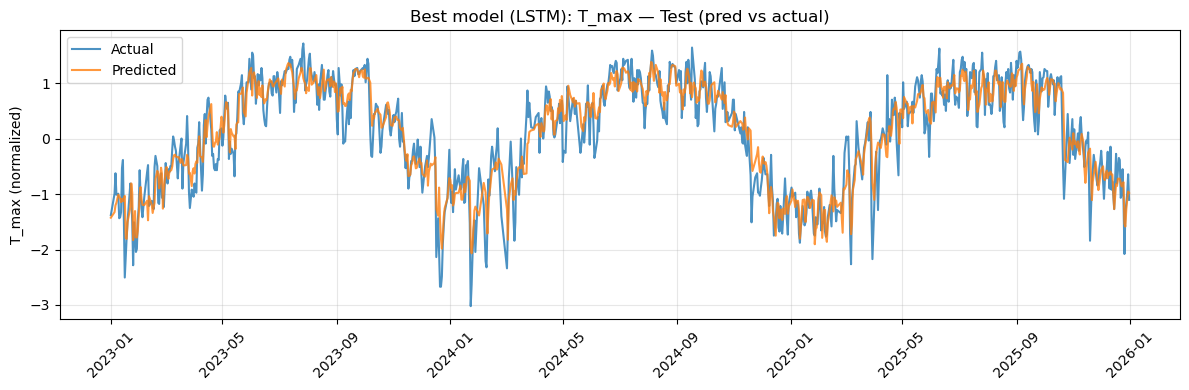

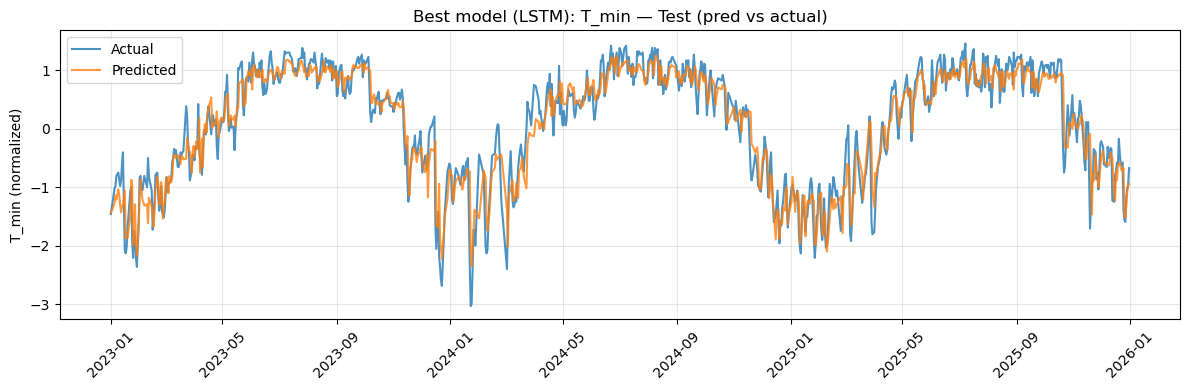

/Users/rain/Desktop/Study/ADA/ADA-group-project/./utils/visualization.py:228: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


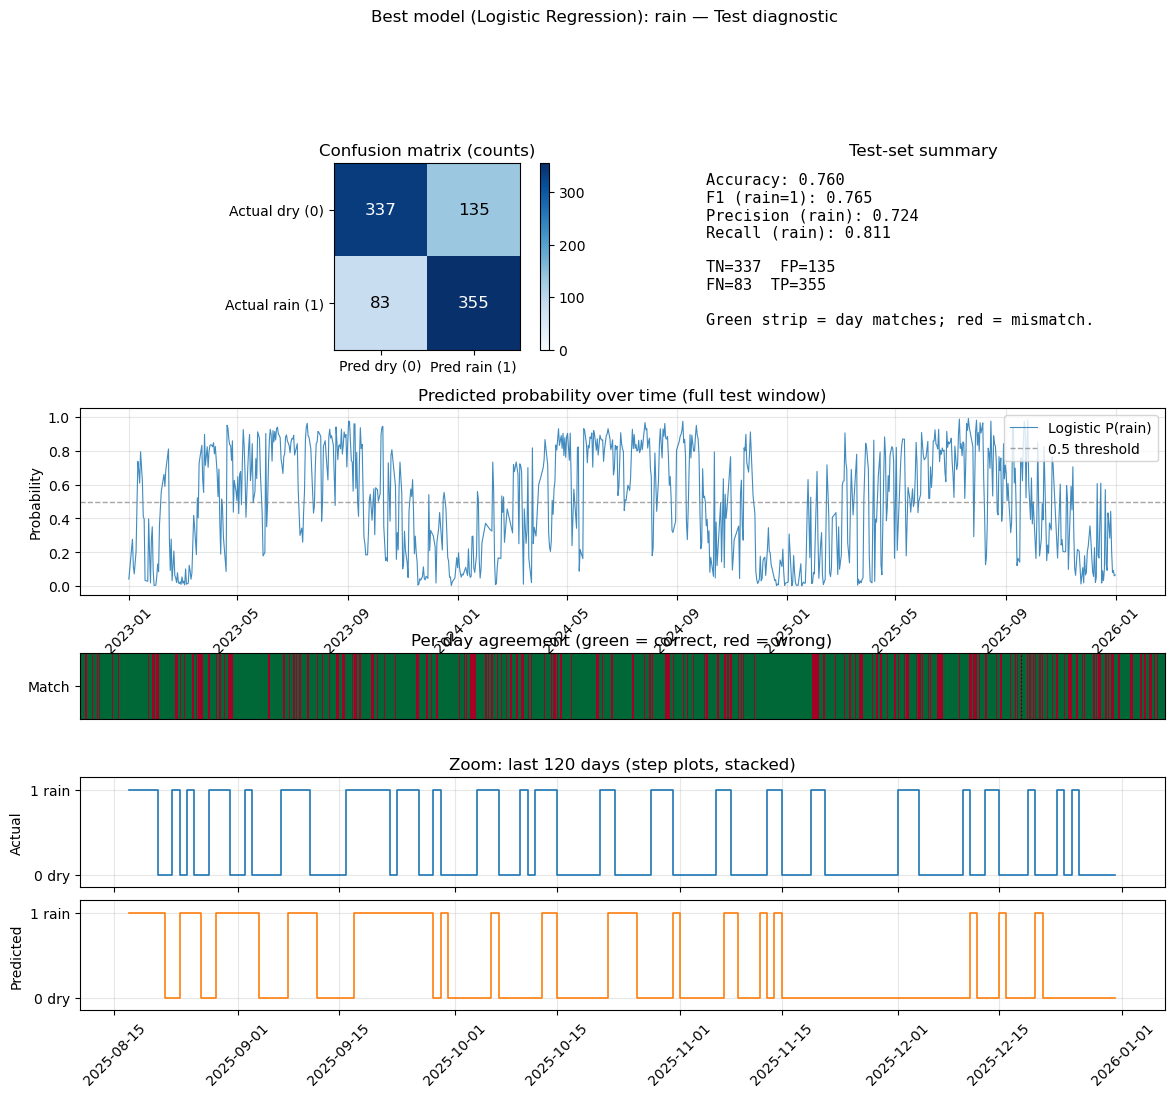

In [15]:
# --- T_max: best regression model (test set) ---
if best_reg_name == "LSTM" and HAS_LSTM and y_lstm_test_pred is not None:
    plot_predictions_vs_actual(
        dates_lstm_test, y_lstm_test, y_lstm_test_pred,
        title=f"Best model ({best_reg_name}): T_max — Test (pred vs actual)",
        ylabel="T_max (normalized)",
    )
else:
    plot_predictions_vs_actual(
        dates_sarima_test, y_sarima_test_actual, y_sarima_test_pred,
        title=f"Best model ({best_reg_name}): T_max — Test (pred vs actual)",
        ylabel="T_max (°C)",
    )

# --- T_min: best regression model (test set) ---
try:
    _ = best_reg_tmin_name
except NameError:
    best_reg_tmin_name = "SARIMA"
dates_sarima_tmin_test = sarima_test_tmin_series.index[:n_tmin]
if best_reg_tmin_name == "LSTM" and HAS_LSTM_TMIN and y_lstm_tmin_test_pred is not None:
    plot_predictions_vs_actual(
        dates_lstm_test, y_lstm_test_tmin, y_lstm_tmin_test_pred,
        title=f"Best model ({best_reg_tmin_name}): T_min — Test (pred vs actual)",
        ylabel="T_min (normalized)",
    )
else:
    plot_predictions_vs_actual(
        dates_sarima_tmin_test, y_sarima_tmin_actual, y_sarima_tmin_pred,
        title=f"Best model ({best_reg_tmin_name}): T_min — Test (pred vs actual)",
        ylabel="T_min (°C)",
    )

# --- Rain: best classifier (test set, 0/1) ---
try:
    _ = best_clf_name
except NameError:
    best_clf_name = "Logistic Regression"

if best_clf_name == "Logistic Regression":
    dates_lr_test = pd.to_datetime(X_lr_test["date"]).values
    plot_rain_classification_diagnostic(
        dates_lr_test,
        y_lr_test.values,
        y_lr_test_pred,
        y_score=y_lr_test_score,
        title="Best model (Logistic Regression): rain — Test diagnostic",
        score_label="Logistic P(rain)",
        zoom_last_days=120,
    )
elif best_clf_name == "LSTM" and HAS_LSTM_RAIN and y_lstm_rain_test_pred is not None:
    plot_rain_classification_diagnostic(
        dates_lstm_test,
        y_lstm_test_rain.astype(int),
        np.asarray(y_lstm_rain_test_pred).astype(int),
        title="Best model (LSTM): rain — Test diagnostic",
        zoom_last_days=120,
    )
else:
    dates_sarima_rain_test = sarima_test_rain_series.index[:n_rain]
    plot_rain_classification_diagnostic(
        dates_sarima_rain_test,
        y_sarima_rain_actual.astype(int),
        y_sarima_rain_pred.astype(int),
        title="Best model (SARIMA): rain — Test diagnostic",
        zoom_last_days=120,
    )


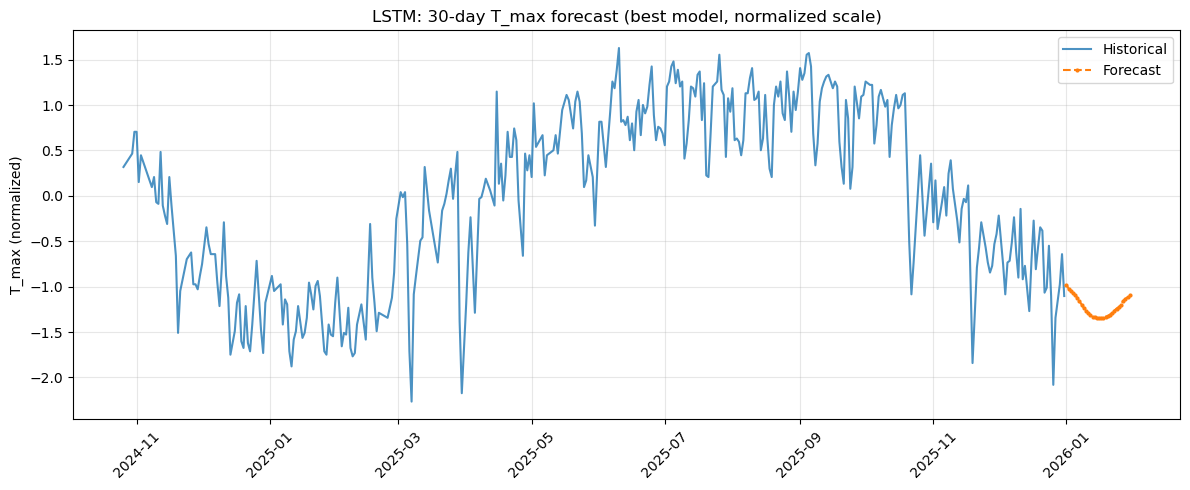

LSTM T_max 30-day forecast (first 5): [-0.97786415 -1.0215755  -1.043108   -1.0683938  -1.0921676 ]


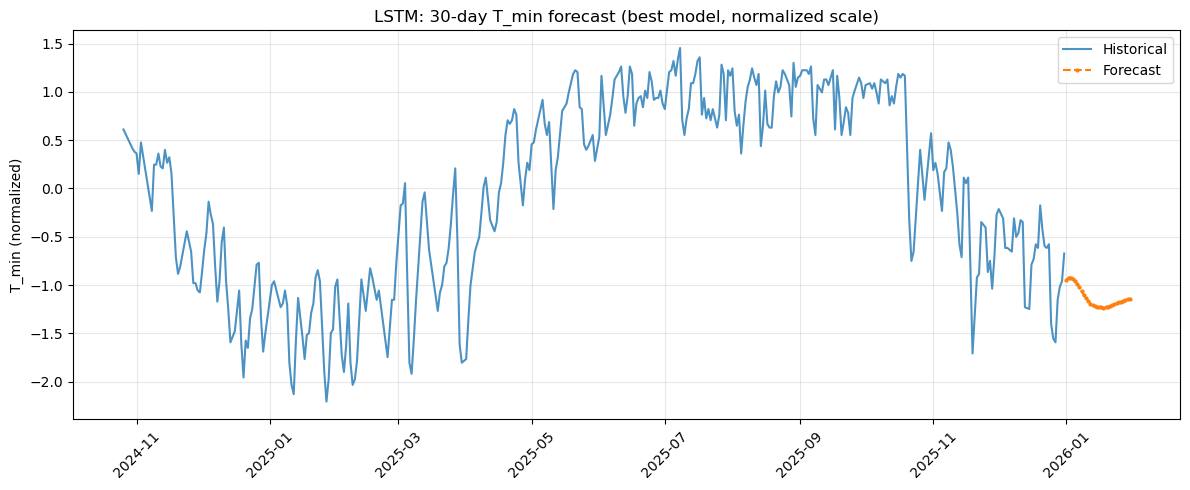

LSTM T_min 30-day forecast (first 5): [-0.9476168  -0.9220586  -0.92211527 -0.9369706  -0.957397  ]
Skipping 30-day rain forecast: best rain model is 'Logistic Regression' — multi-step needs future lags/features (Logistic) or iterative multivariate LSTM; use test-set plot above.


In [16]:
# Future forecast: 30 days beyond last date in df_arima (per target, using best model where supported)
FORECAST_DAYS = 30
last_date_a = pd.Timestamp(df_arima["date"].max())
future_dates_a = pd.date_range(start=last_date_a + pd.Timedelta(days=1), periods=FORECAST_DAYS, freq="D")
hist_dates_a = df_arima["date"].values[-365:]

# --- T_max ---
if best_reg_name == "SARIMA":
    full_series = df_arima.set_index("date")["T_max"].dropna()
    future_pred = fit_and_forecast_test(
        full_series, test_len=FORECAST_DAYS, order=SARIMA_ORDER, seasonal_order=SARIMA_SEASONAL
    )
    hist_values = df_arima.set_index("date").loc[hist_dates_a, "T_max"].values
    plot_future_forecast(
        hist_dates_a, hist_values, future_dates_a, future_pred,
        title="SARIMA: 30-day T_max forecast (best model)",
        ylabel="T_max (°C)",
    )
    print("SARIMA T_max 30-day forecast (first 5):", future_pred[:5])
elif best_reg_name == "LSTM" and HAS_LSTM:
    last_seq = X_lstm_test[-1:].copy()
    lstm_future = []
    for _ in range(FORECAST_DAYS):
        p = predict_lstm(lstm_model, last_seq)[0]
        lstm_future.append(p)
        new_row = last_seq[:, -1:, :].copy()
        new_row[:, :, 0] = p  # T_max channel in LSTM_FEATURE_COLS
        last_seq = np.concatenate([last_seq[:, 1:, :], new_row], axis=1)
    lstm_future = np.array(lstm_future)
    last_date_n = pd.Timestamp(df_norm["date"].max())
    future_dates_n = pd.date_range(start=last_date_n + pd.Timedelta(days=1), periods=FORECAST_DAYS, freq="D")
    hist_dates_n = df_norm["date"].values[-365:]
    hist_values = df_norm["T_max"].values[-365:]
    plot_future_forecast(
        hist_dates_n, hist_values, future_dates_n, lstm_future,
        title="LSTM: 30-day T_max forecast (best model, normalized scale)",
        ylabel="T_max (normalized)",
    )
    print("LSTM T_max 30-day forecast (first 5):", lstm_future[:5])

# --- T_min ---
try:
    _ = best_reg_tmin_name
except NameError:
    best_reg_tmin_name = "SARIMA"

if best_reg_tmin_name == "SARIMA":
    full_tmin = df_arima.set_index("date")["T_min"].dropna()
    future_tmin = fit_and_forecast_test(
        full_tmin, test_len=FORECAST_DAYS, order=SARIMA_ORDER, seasonal_order=SARIMA_SEASONAL
    )
    hist_tmin = df_arima.set_index("date").loc[hist_dates_a, "T_min"].values
    plot_future_forecast(
        hist_dates_a, hist_tmin, future_dates_a, future_tmin,
        title="SARIMA: 30-day T_min forecast (best model)",
        ylabel="T_min (°C)",
    )
    print("SARIMA T_min 30-day forecast (first 5):", future_tmin[:5])
elif best_reg_tmin_name == "LSTM" and HAS_LSTM_TMIN:
    last_seq_t = X_lstm_test_tmin[-1:].copy()
    lstm_future_tmin = []
    for _ in range(FORECAST_DAYS):
        p = predict_lstm(lstm_model_tmin, last_seq_t)[0]
        lstm_future_tmin.append(p)
        new_row = last_seq_t[:, -1:, :].copy()
        new_row[:, :, 1] = p  # T_min channel in LSTM_FEATURE_COLS
        last_seq_t = np.concatenate([last_seq_t[:, 1:, :], new_row], axis=1)
    lstm_future_tmin = np.array(lstm_future_tmin)
    last_date_n = pd.Timestamp(df_norm["date"].max())
    future_dates_n = pd.date_range(start=last_date_n + pd.Timedelta(days=1), periods=FORECAST_DAYS, freq="D")
    hist_dates_n = df_norm["date"].values[-365:]
    hist_vals_tmin = df_norm["T_min"].values[-365:]
    plot_future_forecast(
        hist_dates_n, hist_vals_tmin, future_dates_n, lstm_future_tmin,
        title="LSTM: 30-day T_min forecast (best model, normalized scale)",
        ylabel="T_min (normalized)",
    )
    print("LSTM T_min 30-day forecast (first 5):", lstm_future_tmin[:5])

# --- Rain (mm): only univariate SARIMA multi-step is shown here ---
try:
    _ = best_clf_name
except NameError:
    best_clf_name = "Logistic Regression"

if best_clf_name == "SARIMA":
    full_rain = df_arima.set_index("date")["rain_mm"].dropna()
    future_rain = fit_and_forecast_test(
        full_rain, test_len=FORECAST_DAYS, order=SARIMA_ORDER, seasonal_order=SARIMA_SEASONAL
    )
    hist_rain = df_arima.set_index("date").loc[hist_dates_a, "rain_mm"].values
    plot_future_forecast(
        hist_dates_a, hist_rain, future_dates_a, future_rain,
        title="SARIMA: 30-day rain_mm forecast (best rain model)",
        ylabel="rain_mm",
    )
    print("SARIMA rain_mm 30-day forecast (first 5):", future_rain[:5])
else:
    print(
        "Skipping 30-day rain forecast: best rain model is",
        repr(best_clf_name),
        "— multi-step needs future lags/features (Logistic) or iterative multivariate LSTM; use test-set plot above."
    )


### 3.2 Insights and recommendations

- **Regression (T_max)**: Compare LSTM and SARIMA test RMSE/MAE/MAPE. The model with lower error is better for short-term temperature forecasting. SARIMA uses only past T_max and seasonality; LSTM can use multiple weather variables and may capture non-linear patterns.
- **Classification (rain)**: Logistic Regression with lag/rolling features gives a baseline for rain yes/no. Higher F1 indicates better trade-off between precision and recall.
- **Recommendations**: Use the best regression model for operational T_max forecasts. For rain, consider collecting more features or trying LSTM for rain classification if needed. Monitor MAPE on test to avoid overfitting; if MAPE is high, consider simpler models or more data.

## [optional] some discarded candidate features

Combined dataset loaded with original features only:
Columns: ['date', 'T_max', 'T_min', 'rain_mm', 'RH_mean', 'cloud', 'MSLP', 'DEW', 'SST', 'WET', 'GMT', 'T_mean']
Shape: (5479, 12)
        date  T_max  T_min  rain_mm  RH_mean  cloud    MSLP   DEW   SST   WET  \
0 2011-01-01   17.2   12.7      0.0     57.0   14.0  1019.1   6.3  18.7  10.8   
1 2011-01-02   16.3   14.1      0.0     65.0   83.0  1019.8   8.5  18.6  11.8   
2 2011-01-03   15.5   12.6      NaN     72.0   91.0  1019.6   9.0  18.1  11.5   
3 2011-01-04   14.6   12.1      1.2     81.0   95.0  1020.4  10.3  17.8  11.8   
4 2011-01-05   17.9   13.9      0.0     77.0   91.0  1018.6  11.8  17.8  13.6   

    GMT  T_mean  
0  10.3    14.9  
1  12.3    15.1  
2  14.0    14.0  
3  12.8    13.4  
4  13.6    15.7  

Original numeric features for correlation: ['T_max', 'T_min', 'rain_mm', 'RH_mean', 'cloud', 'MSLP', 'DEW', 'SST', 'WET', 'GMT', 'T_mean']

Correlation Matrix (11 variables):
            T_max     T_min   rain_mm   RH_me

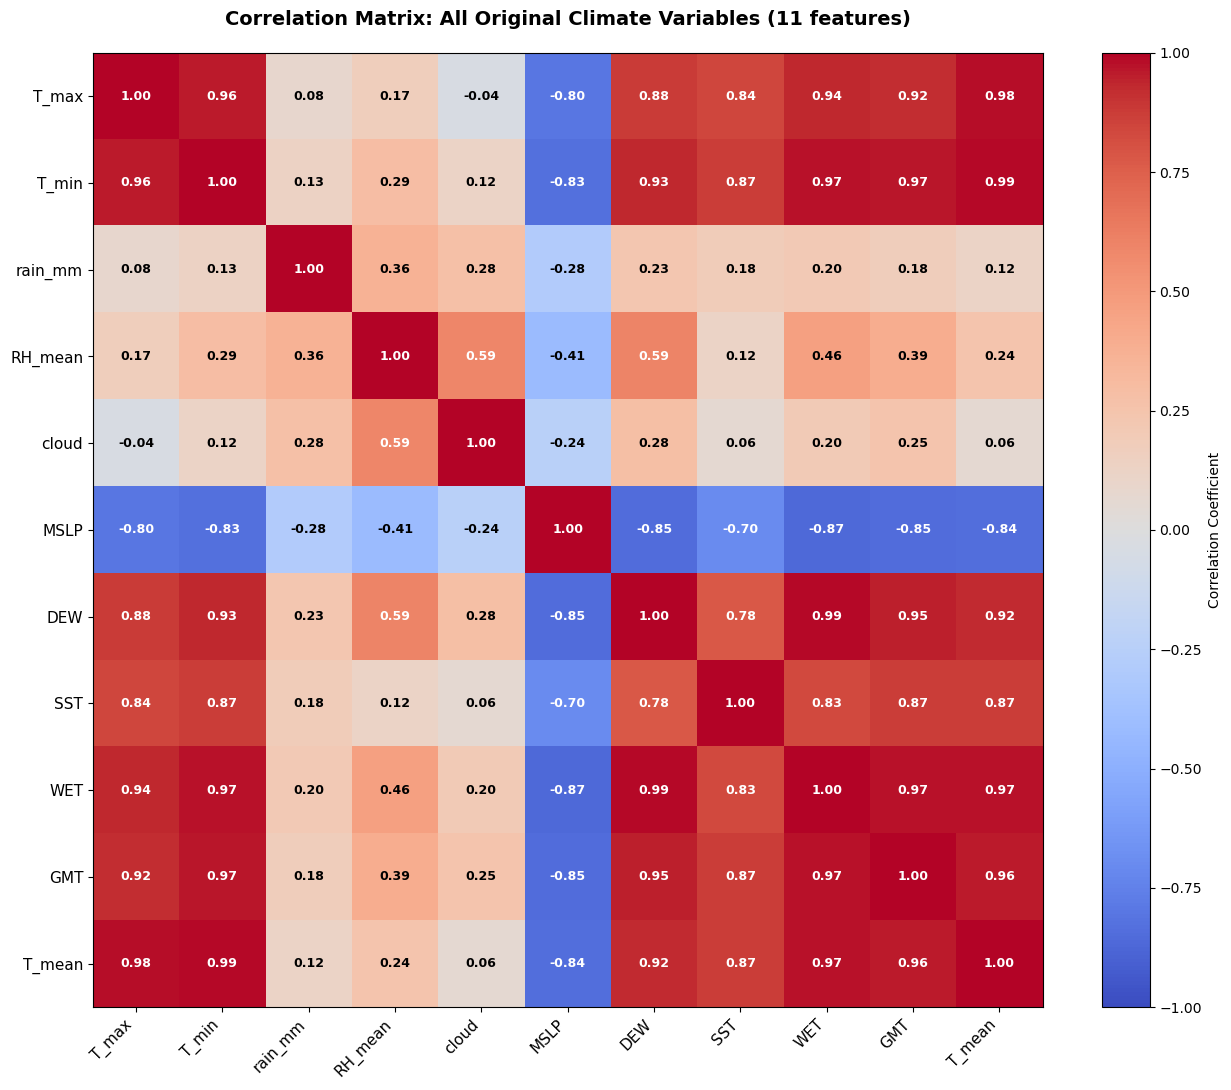


Correlation analysis completed successfully.


In [7]:
from pathlib import Path

# Optional extra HKO daily CSV exports (same format as other HKO files); merged when present
additional_files = [
    ("data/DEW.csv", "DEW"),
    ("data/SST.csv", "SST"),
    ("data/WET.csv", "WET"),
    ("data/GMT.csv", "GMT"),
    ("data/T_mean.csv", "T_mean"),
]

def load_and_preprocess_hko_file(file_path, feature_name):
    # Load HKO file (skip first 3 metadata rows)
    df = pd.read_csv(
        file_path,
        skiprows=3,
        header=None,
        names=["Year", "Month", "Day", "Value", "Completeness"],
        encoding="utf-8-sig",
    )

    # Parse date fields safely
    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
    df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
    df["Day"] = pd.to_numeric(df["Day"], errors="coerce")
    df = df.dropna(subset=["Year", "Month", "Day"]).copy()

    # Keep only 2011-2025
    df["Year"] = df["Year"].astype(int)
    df["Month"] = df["Month"].astype(int)
    df["Day"] = df["Day"].astype(int)
    df = df[(df["Year"] >= 2011) & (df["Year"] <= 2025)].copy()

    # Mark non-C completeness rows as missing
    completeness = df["Completeness"].astype(str).str.strip()
    df.loc[completeness != "C", "Value"] = pd.NA

    # Convert value to numeric
    df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

    # Create date column
    df["date"] = pd.to_datetime(df[["Year", "Month", "Day"]], errors="coerce")
    df = df.dropna(subset=["date"]).copy()
    df = df[["date", "Value"]].rename(columns={"Value": feature_name})

    return df

# Load the original HKO dataset (reload from saved csv for synchronization)
dataset_original = pd.read_csv('data/dataset_raw.csv')
dataset_original['date'] = pd.to_datetime(dataset_original['date'])
original_cols = ['T_max', 'T_min', 'rain_mm', 'RH_mean', 'cloud', 'MSLP']

# Start with original columns only (exclude derived features like DTR, rain_freq, MSLP_delta)
dataset_combined = dataset_original[['date'] + original_cols].copy()

# Load and merge additional datasets (skip files not yet added under data/)
for file_name, feature_name in additional_files:
    if not Path(file_name).is_file():
        print(f"Skipping missing file: {file_name} (add this HKO export to include {feature_name})")
        continue
    additional_df = load_and_preprocess_hko_file(file_name, feature_name)
    dataset_combined = pd.merge(dataset_combined, additional_df, on="date", how="inner")

print("Combined dataset loaded with original features only:")
print(f"Columns: {dataset_combined.columns.tolist()}")
print(f"Shape: {dataset_combined.shape}")
print(dataset_combined.head())

# Extract numeric columns only (all original features)
numeric_cols = dataset_combined.select_dtypes(include=[np.number]).columns.tolist()
numeric_data = dataset_combined[numeric_cols]

print(f"\nOriginal numeric features for correlation: {numeric_cols}")

# Calculate correlation matrix
corr_matrix = numeric_data.corr()

n_vars = len(corr_matrix.columns)
print(f"\nCorrelation Matrix ({n_vars} variables):")
print(corr_matrix)

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)

# Set ticks and labels
ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right', fontsize=11)
ax.set_yticklabels(corr_matrix.columns, fontsize=11)

# Add correlation values as text
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        value = corr_matrix.iloc[i, j]
        color = "white" if abs(value) > 0.5 else "black"
        text = ax.text(j, i, f'{value:.2f}',
                      ha="center", va="center", color=color, fontsize=9, fontweight='bold')

ax.set_title('Correlation Matrix: All Original Climate Variables (11 features)',
             fontsize=14, fontweight='bold', pad=20)
cbar = fig.colorbar(im, ax=ax, label='Correlation Coefficient')
plt.tight_layout()
plt.show()

print("\nCorrelation analysis completed successfully.")
